In [1]:
%load_ext autoreload
%autoreload 2

# ==========================================================
#                     IMPORTS
# ==========================================================
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
from jax import config
from jax_cosmo import Cosmology
import jax_cosmo.background as bkgrd
from jax_cosmo.background import angular_diameter_distance, radial_comoving_distance

# Affiche les devices
print("Local devices:", jax.local_device_count(), flush=True)
print("Total devices:", jax.device_count(), flush=True)

jax.config.update("jax_enable_x64", True)
from jax.lib import xla_bridge
#platform = xla_bridge.get_backend().platform
#jax.config.update('jax_platform_name', platform)

# ==========================================================
#                     NUMPYRO CONFIG
# ==========================================================
import numpyro
numpyro.set_platform("cpu")
numpyro.enable_x64()
numpyro.set_host_device_count(jax.device_count())
from numpyro.handlers import seed, trace, condition
from numpyro.infer.reparam import LocScaleReparam, TransformReparam
from numpyro.infer import HMC, HMCECS, MCMC, NUTS, SA, SVI, Trace_ELBO, init_to_value
from numpyro.distributions.transforms import AffineTransform
import numpyro.distributions as dist
# Number of threads or devices (GPU/CPU) for numpyro, useful for parallelization
#numpyro.set_host_device_count(4)

# ==========================================================
#                     LIBRARIES DIVERSES
# ==========================================================
import pickle as pk
import numpy as np
import colossus 
import configobj
import copy
import yaml
from deepmerge import always_merger
import ast 
import time
from astropy import constants as const
import pathlib
from scipy.interpolate import interp1d
from astropy.io import fits
from tqdm import tqdm
import matplotlib.pyplot as pl
import copy
import getdist
from getdist import plots, MCSamples
import dill as dill
import arviz as az
import time

# ==========================================================
#                     GODMAX LIBRARY
# ==========================================================
import godmax
from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi
from godmax.get_covs import get_cov

print("Imports done", flush=True)



/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound
ERROR:2026-03-27 16:23:23,975:jax._src.xla_bridge:475: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 473, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/vtinnane/micromamba/envs/tSZxEuclid

Local devices: 1
Total devices: 1


/tmp/ipykernel_1205449/2546069585.py:23: DeprecationWarning: jax.lib.xla_bridge module will be removed in JAX v0.9.0; all its APIs were deprecated and removed by JAX v0.8.0.
  from jax.lib import xla_bridge
/home/vtinnane/micromamba/envs/tSZxEuclid-godmax/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports done


In [2]:
# ==========================================================
#                     PATHS
# ==========================================================
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../figures/godmax/test_covG/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append(str(curr_path))
sys.path.append(str(abs_path_data))
sys.path.append(str(abs_path_results))
sys.path.append(str(abs_path_src))

# =====================================================================
#                         LOAD PARAM FILES
# =====================================================================
def read_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

params_default = read_yaml("../../../params_godmax/params_default.yaml")
params_pge     = read_yaml("../../../params_godmax/Pge/params.yaml")

# merge simple (on écrase par pge)
sim_params_dict     = {**params_default["sim_params"], **params_pge["sim_params"]}
halo_params_dict    = {**params_default["halo_params"], **params_pge["halo_params"]}
analysis_dict       = {**params_default["analysis"],    **params_pge["analysis"]}
other_params_dict   = {**params_default["other_params"],**params_pge["other_params"]}

In [14]:
# =====================================================================
#                DEFINE COSMOLOGY
# =====================================================================

cosmo_params = sim_params_dict.get('cosmo')
cosmo_jax = Cosmology(
            Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
            Omega_b=cosmo_params['Ob0'],
            h=cosmo_params['H0'] / 100.,
            sigma8=cosmo_params['sigma8'],
            n_s=cosmo_params['ns'],
            Omega_k=0.,
            w0=cosmo_params['w0'],
            wa=0.
            )

# =====================================================================
#                DEFINE ELL and K ARRAYs — REQUIRED FOR THEORY
# =====================================================================
lmin, lmax, dl_log_array = 1000.0, 7000.0, 0.02325851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array    = l_array_all[1:] - l_array_all[:-1]        # delta ell in each bin
l_array_eff = (l_array_all[1:] + l_array_all[:-1]) / 2. # effective ell in each bin
halo_params_dict['ell_array']    = jnp.array(l_array_eff)
analysis_dict['l_array_survey']  = jnp.array(l_array_eff)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)

#ks = np.geomspace(3e-1,10,10) 
#analysis_dict['k_array_survey'] = jnp.array(ks / (sim_params_dict['cosmo']['H0']/100.))

In [ ]:
# ==========================================================
#             GALAXY COMOVING NON-NORMALIZED NZ
# ==========================================================

def to_comoving_nz(z_array, nz_array, cosmo):
    """ Convert a non-normalized n(z) to comoving n(z) 
    - nz_array : non-normalized n(z) in redshift bins [#gal/z]
    - z_array  : redshift bin centers
    - cosmo    : jax-cosmo Cosmology object
    Returns :
    - nz_comoving : comoving n(z) in [(Mpc/h)^-3]
    """
    
    # Compute dV/dz/dOmega
    scale_fac_a_array = 1.0 / (1.0 + z_array)
    chi_array = radial_comoving_distance(cosmo, scale_fac_a_array)
    dchi_dz_array = (const.c.value * 1e-3) / bkgrd.H(cosmo, scale_fac_a_array)
    dV_dzdOmega_array = chi_array**2 * dchi_dz_array

    # Comoving n(z)
    nz_comoving = nz_array / dV_dzdOmega_array

    return nz_comoving

# Load the galaxy n(z)
dndz_gal_file = np.loadtxt('../../../Data/dndz/nz_euclid_forecast_bin-all.txt') #non-normalized Euclid forecast N(z)
z_gal      = dndz_gal_file[:,0]
nz_gal     = dndz_gal_file[:,1]

# Convert to comoving n(z)
nz_gal_comoving = to_comoving_nz(z_gal, nz_gal, cosmo_jax)
# Store the galaxy n(z)
analysis_dict['nbar_gal_comoving_zarray'] = z_gal
analysis_dict['nbar_gal_comoving_val']    = nz_gal_comoving

# ==========================================================
#                     LENS NZ BINS
# ==========================================================
# Define lensing n(z) for 6 lens bins
nz_lens = {}
nz_info_dict = {}

# Number of lensing redshift bins
nbins_lens = 2
nz_info_dict['nbins_lens'] = nbins_lens

# Load each lensing bin n(z)
for nbin in range(nbins_lens):
    nz_lens_nbin = np.loadtxt('../../../Data/dndz/nz_norm_euclid_forecast_bin-' + str(nbin+1) + '.txt') #normalized bin n(z)
    nz_lens[nbin] = nz_lens_nbin[:,1]
    nz_info_dict['nz'+str(nbin)] = nz_lens[nbin]

# Store the z array (same for all bins)
z_lens = nz_lens_nbin[:,0]
nz_info_dict['z_array_lens'] = z_lens

# Store in analysis dict
analysis_dict['nz_lens_info_dict'] = nz_info_dict

# ==========================================================
#           SOURCE NZ BINS (same as lens here)
# ==========================================================
# Define source n(z) for 6 source bins
nz_source = {}
nz_info_dict = {}

# Number of source redshift bins
nbins_source = 2
nz_info_dict['nbins'] = nbins_source

# Load each source bin n(z)
for nbin in range(nbins_source):
    nz_source_nbin = np.loadtxt('../../../Data/dndz/nz_norm_euclid_forecast_bin-' + str(nbin+1) + '.txt') #normalized bin n(z)
    nz_source[nbin] = nz_source_nbin[:,1]
    nz_info_dict['nz'+str(nbin)] = nz_source[nbin]

# Store the z array (same for all bins)
z_source = nz_source_nbin[:,0]
nz_info_dict['z_array_source'] = z_source

analysis_dict['nz_source_info_dict'] = nz_info_dict

print("N(z) files loaded", flush=True)

from scipy.interpolate import interp1d

deg2_to_arcmin2 = 3600.0

nz_gal_interp = interp1d(z_gal, nz_gal, bounds_error=False, fill_value=0.0)
nz_gal_on_zlens = nz_gal_interp(z_lens)

# stack normalized bin PDFs
pz_bins = np.vstack([nz_lens[jb] for jb in range(nbins_lens)])   # shape (nbins, Nz)
pz_sum = np.sum(pz_bins, axis=0)

nbar_lens_bins = np.zeros(nbins_lens)

for jb in range(nbins_lens):
    frac_j = np.zeros_like(z_lens)
    valid = pz_sum > 0
    frac_j[valid] = pz_bins[jb, valid] / pz_sum[valid]

    nbar_deg2 = np.trapezoid(nz_gal_on_zlens * frac_j, z_lens)
    nbar_lens_bins[jb] = nbar_deg2 / deg2_to_arcmin2

analysis_dict['nbar_lens_bins'] = nbar_lens_bins

print("Per-bin nbar:")
for jb in range(nbins_lens):
    nbar_arcmin2 = nbar_lens_bins[jb]
    nbar_sr = nbar_arcmin2 * (180.0 * 60.0 / np.pi)**2
    print(
        f"  bin {jb+1}: {nbar_arcmin2:.3f} gal/arcmin²  |  "
        f"{nbar_sr:.3e} gal/sr  |  shot noise = {1/nbar_sr:.3e}"
    )

print(f"Total: {np.sum(nbar_lens_bins):.3f} gal/arcmin²")

N(z) files loaded


In [16]:
# from scipy.interpolate import interp1d

# deg2_to_arcmin2 = 3600.0

# # interpolate all-bin absolute n(z) onto lens z grid
# nz_gal_interp = interp1d(z_gal, nz_gal, bounds_error=False, fill_value=0.0)
# nz_gal_on_zlens = nz_gal_interp(z_lens)

# nbar_lens_bins = np.zeros(nbins_lens)

# for jb in range(nbins_lens):
#     # support of tomographic bin jb
#     in_bin = nz_lens[jb] > 1e-10

#     if np.sum(in_bin) > 1:
#         # integrate absolute all-bin n(z) over that bin support
#         nbar_deg2 = np.trapezoid(nz_gal_on_zlens[in_bin], z_lens[in_bin])
#         nbar_lens_bins[jb] = nbar_deg2 / deg2_to_arcmin2   # gal/arcmin²

# analysis_dict['nbar_lens_bins'] = nbar_lens_bins

# print("Per-bin nbar:")
# for jb in range(nbins_lens):
#     nbar_arcmin2 = nbar_lens_bins[jb]
#     nbar_sr = nbar_arcmin2 * (180.0 * 60.0 / np.pi)**2
#     print(
#         f"  bin {jb+1}: {nbar_arcmin2:.3f} gal/arcmin²  |  "
#         f"{nbar_sr:.3e} gal/sr  |  shot noise = {1/nbar_sr:.3e}"
#     )

# print(f"Total: {np.sum(nbar_lens_bins):.3f} gal/arcmin²")

from scipy.interpolate import interp1d

deg2_to_arcmin2 = 3600.0

nz_gal_interp = interp1d(z_gal, nz_gal, bounds_error=False, fill_value=0.0)
nz_gal_on_zlens = nz_gal_interp(z_lens)

# stack normalized bin PDFs
pz_bins = np.vstack([nz_lens[jb] for jb in range(nbins_lens)])   # shape (nbins, Nz)
pz_sum = np.sum(pz_bins, axis=0)

nbar_lens_bins = np.zeros(nbins_lens)

for jb in range(nbins_lens):
    frac_j = np.zeros_like(z_lens)
    valid = pz_sum > 0
    frac_j[valid] = pz_bins[jb, valid] / pz_sum[valid]

    nbar_deg2 = np.trapezoid(nz_gal_on_zlens * frac_j, z_lens)
    nbar_lens_bins[jb] = nbar_deg2 / deg2_to_arcmin2

analysis_dict['nbar_lens_bins'] = nbar_lens_bins

print("Per-bin nbar:")
for jb in range(nbins_lens):
    nbar_arcmin2 = nbar_lens_bins[jb]
    nbar_sr = nbar_arcmin2 * (180.0 * 60.0 / np.pi)**2
    print(
        f"  bin {jb+1}: {nbar_arcmin2:.3f} gal/arcmin²  |  "
        f"{nbar_sr:.3e} gal/sr  |  shot noise = {1/nbar_sr:.3e}"
    )

print(f"Total: {np.sum(nbar_lens_bins):.3f} gal/arcmin²")

Per-bin nbar:
  bin 1: 3.333 gal/arcmin²  |  3.939e+07 gal/sr  |  shot noise = 2.539e-08
  bin 2: 1.635 gal/arcmin²  |  1.933e+07 gal/sr  |  shot noise = 5.174e-08
Total: 4.968 gal/arcmin²


In [17]:
other_params_dict

{'A_IA': 0,
 'eta_IA': 0,
 'z0_IA': 0.62,
 'C1_rhocrit': 0.0134,
 'alpha_ky': 1.0,
 'alpha_gy': 1.0,
 'Delta_z_bias_array': [0.0, 0.0, 0.0, 0.0, 0.0],
 'mult_shear_bias_array': [0.0, 0.0, 0.0, 0.0, 0.0]}

In [18]:
def make_yy_white_noise_file(
    ell_array,
    fname,
    N0_y2sr=None,
    beam_fwhm_arcmin=1.4,
    debeam=False,
):
    """
    Generate a simple white-noise yy power spectrum file.

    Parameters
    ----------
    ell_array : array
        Multipoles at which to evaluate the noise.
    fname : str
        Output filename (two-column: ell, N_ell).
    N0_y2sr : float or None
        White noise floor in y^2 sr.  If None, uses the analytic ILC
        estimate from SO LAT baseline specs.
    beam_fwhm_arcmin : float
        Beam FWHM in arcmin.  Used only when debeam=True.
    debeam : bool
        If False (default): return flat N_ell = N0 (noise in the BEAMED
        y-map, consistent with GODMAX applying B_l^2 to the signal).
        If True: return N0 * exp(l(l+1)*sigma^2) — noise on the
        debeamed y-map.
    """
    if N0_y2sr is None:
        # Analytic ILC white-noise estimate from SO LAT baseline (Table 1, 1808.07445)
        # N0 = 1 / sum_nu [ f(nu)^2 / sigma_nu^2 ]
        T_CMB = 2.7255   # K
        so_lat = [         # (GHz, uK-arcmin baseline)
            (27,  71.0),
            (39,  36.0),
            (93,   8.0),
            (145, 30.0),
            (225, 22.0),
            (280, 54.0),
        ]
        h, kb = 6.626e-34, 1.381e-23
        inv_sum = 0.0
        for nu_GHz, w_uKarcmin in so_lat:
            x    = h * nu_GHz * 1e9 / (kb * T_CMB)
            f_K  = T_CMB * (x / np.tanh(x / 2) - 4)          # K per y
            w_K  = w_uKarcmin * 1e-6 * np.pi / (180 * 60)    # K·rad (= K·sr^0.5 per rad)
            Nl   = w_K ** 2                                    # K^2 sr
            inv_sum += f_K ** 2 / Nl
        N0_y2sr = 1.0 / inv_sum
        print(f"Analytic SO LAT white noise floor: N0 = {N0_y2sr:.3e} y^2 sr")

    ell = np.asarray(ell_array, dtype=float)
    if debeam:
        sigma = beam_fwhm_arcmin * np.pi / (180 * 60) / np.sqrt(8 * np.log(2))
        Nl = N0_y2sr * np.exp(ell * (ell + 1) * sigma ** 2)
    else:
        Nl = N0_y2sr * np.ones_like(ell)

    np.savetxt(fname, np.column_stack([ell, Nl]),
                header="ell  N_ell^yy (y^2 sr, white noise)")
    return Nl


In [19]:

from matplotlib.lines import Line2D


def plot_cl_per_probe(
    get_cl,
    cov_obj,
    results_path,
    probes_to_show=("yy", "kk", "gg"),
    scale_factor=1e12,
    yy_extra_noises=None,
    show_plot=True,
):
    """
    Generate and save one plot per probe (yy, kk, gg).

    Parameters
    ----------
    get_cl : object
        Must contain `Cl_1h2h_dict` with key 'ell' and per-probe curve lists.
    cov_obj : object
        Must contain `Cl_plot_dict`.
    results_path : str
        Directory where figures are saved.
    probes_to_show : tuple/list, optional
        Probes to plot.
    scale_factor : float, optional
        Extra multiplicative factor applied after ell(ell+1)/2pi for noise-like curves,
        and directly to the 1h/2h/tot curves to preserve your current plotting logic.
    yy_extra_noises : list of dict or None, optional
        Optional extra yy noise curves to overlay.
        Each entry should look like:
            {
                "ell": ell_array,          # optional; if omitted, uses main ell
                "cl": noise_cl_array,      # required
                "label": "SO LAT noise",   # required
                "color": "orange",         # optional
                "ls": "--",                # optional
                "lw": 1.2                  # optional
            }
        These are plotted only on the yy panel.
    show_plot : bool, optional
        Whether to display the plot interactively.
    """
    os.makedirs(results_path, exist_ok=True)

    ell = np.array(get_cl.Cl_1h2h_dict["ell"])
    ell_fac = ell * (ell + 1) / (2.0 * np.pi)

    type_colors = {
        "tot": "black",
        "1h": "red",
        "2h": "green",
        "noise": "blue",
        "theory_plus_noise": "magenta",
    }

    bin_styles = ["-", "--", ":", "-.", (0, (5, 2))]
    probe_order = [p for p in probes_to_show if p in get_cl.Cl_1h2h_dict]

    for probe in probe_order:
        fig, ax = pl.subplots(figsize=(10, 6))
        curves = get_cl.Cl_1h2h_dict[probe]

        noise_dl = []
        theory_plus_noise_dl = []

        if probe in cov_obj.Cl_plot_dict:
            for _, entry in cov_obj.Cl_plot_dict[probe].items():
                if "noise" in entry:
                    noise_dl.append(ell_fac * np.abs(np.array(entry["noise"])))
                theory_plus_noise_dl.append(
                    ell_fac * np.abs(np.array(entry["theory_plus_noise"]))
                )

        has_noise = len(noise_dl) > 0

        for ic, curve in enumerate(curves):
            ls = bin_styles[ic % len(bin_styles)]
            lbl = curve["label"]

            ax.loglog(
                ell,
                np.abs(np.array(curve["tot"])) * scale_factor,
                color=type_colors["tot"],
                ls=ls,
                lw=1.8,
                label=lbl,
            )
            ax.loglog(
                ell,
                np.abs(np.array(curve["1h"])) * scale_factor,
                color=type_colors["1h"],
                ls="-.",
                lw=1.2,
            )
            ax.loglog(
                ell,
                np.abs(np.array(curve["2h"])) * scale_factor,
                color=type_colors["2h"],
                ls="--",
                lw=1.2,
            )

            if ic < len(noise_dl):
                ax.loglog(
                    ell,
                    noise_dl[ic] * scale_factor,
                    color=type_colors["noise"],
                    ls=":",
                    lw=1.2,
                )

            if ic < len(theory_plus_noise_dl):
                ax.loglog(
                    ell,
                    theory_plus_noise_dl[ic] * scale_factor,
                    color=type_colors["theory_plus_noise"],
                    ls=ls,
                    lw=1.0,
                )

        extra_handles = []
        if probe == "yy" and yy_extra_noises is not None:
            for i, noise_spec in enumerate(yy_extra_noises):
                if "cl" not in noise_spec or "label" not in noise_spec:
                    raise ValueError(
                        "Each yy_extra_noises entry must contain at least 'cl' and 'label'."
                    )

                noise_ell = np.array(noise_spec.get("ell", ell))
                noise_cl = np.array(noise_spec["cl"])
                noise_label = noise_spec["label"]
                noise_color = noise_spec.get("color", f"C{i}")
                noise_ls = noise_spec.get("ls", "--")
                noise_lw = noise_spec.get("lw", 1.2)

                if noise_ell.shape != noise_cl.shape:
                    raise ValueError(
                        f"yy extra noise '{noise_label}' has mismatched ell/cl shapes: "
                        f"{noise_ell.shape} vs {noise_cl.shape}"
                    )

                noise_ell_fac = noise_ell * (noise_ell + 1) / (2.0 * np.pi)

                ax.loglog(
                    noise_ell,
                    np.abs(noise_cl) * noise_ell_fac * scale_factor,
                    color=noise_color,
                    ls=noise_ls,
                    lw=noise_lw,
                    label=noise_label,
                )

                extra_handles.append(
                    Line2D([], [], color=noise_color, ls=noise_ls, lw=noise_lw, label=noise_label)
                )

        noise_label = {
            "kk": "shape noise",
            "gg": "shot noise",
            "yy": "map noise",
        }.get(probe, "noise")

        type_handles = [
            Line2D([], [], color="black", lw=1.8, label="total (1h+2h)"),
            Line2D([], [], color="red", lw=1.2, label="1h"),
            Line2D([], [], color="green", lw=1.2, label="2h"),
        ]

        if has_noise:
            type_handles += [
                Line2D([], [], color="blue", lw=1.2, label=noise_label),
                Line2D([], [], color="magenta", lw=1.0, label="theory + noise"),
            ]

        type_handles += extra_handles
        ax.legend(handles=type_handles, fontsize=12, loc="upper left")

        ax.set_title(probe, fontsize=16)
        ax.set_xlabel(r"$\ell$", fontsize=14)
        ax.set_ylabel(r"$10^{12}\,\ell(\ell+1)C_\ell / 2\pi$", fontsize=14)
        ax.grid(True, which="both", alpha=0.3)

        save_path = os.path.join(results_path, f"cl_{probe}.png")
        pl.tight_layout()
        pl.savefig(save_path, dpi=300, bbox_inches="tight")

        if show_plot:
            pl.show()
        else:
            pl.close(fig)

        print(f"Saved: {save_path}")

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Labels for block plots
# ─────────────────────────────────────────────────────────────────────────────
def format_block_label(probe, bins):
    b1, b2 = bins

    if probe == "yy":
        return "yy"
    if probe in ["ky", "gy"]:
        return f"{probe}[{b1}]"
    if probe in ["kk", "gg", "gk"]:
        return f"{probe}[{b1},{b2}]"
    return f"{probe}{bins}"


def decorate_block_matrix(ax, bin_comb_all, nell, fontsize=7, rotate_labels=True):
    nblocks = len(bin_comb_all)
    nell_all = nblocks * nell

    for k in range(1, nblocks):
        pos = k * nell - 0.5
        ax.axhline(pos, color="white", lw=0.5, alpha=0.7)
        ax.axvline(pos, color="white", lw=0.5, alpha=0.7)

    centers = np.arange(nblocks) * nell + 0.5 * (nell - 1)
    labels = [format_block_label(probe, bins) for probe, bins in bin_comb_all]

    ax.set_xticks(centers)
    ax.set_yticks(centers)
    ax.set_xticklabels(labels, rotation=90 if rotate_labels else 0, fontsize=fontsize)
    ax.set_yticklabels(labels, fontsize=fontsize)

    ax.set_xlim(-0.5, nell_all - 0.5)
    ax.set_ylim(-0.5, nell_all - 0.5)


# ─────────────────────────────────────────────────────────────────────────────
# Build ordering DIRECTLY from cov_obj.Cl_result_dict
# ─────────────────────────────────────────────────────────────────────────────
def build_bin_comb_all_from_cov(cov_obj, probes_analysis):
    """
    Use the exact bin ordering stored inside cov_obj.Cl_result_dict,
    but drop redundant lower-triangle entries for symmetric auto-spectra
    like kk and gg.
    """
    bin_comb_all = []

    for probe in probes_analysis:
        if probe not in cov_obj.Cl_result_dict:
            raise KeyError(f"Probe '{probe}' not found in cov_obj.Cl_result_dict")

        if "bin_combs" not in cov_obj.Cl_result_dict[probe]:
            raise KeyError(f"Probe '{probe}' missing 'bin_combs' in cov_obj.Cl_result_dict")

        raw_bin_combs = cov_obj.Cl_result_dict[probe]["bin_combs"]

        if probe in ["kk", "gg"]:
            raw_bin_combs = [bc for bc in raw_bin_combs if bc[0] <= bc[1]]

        for b1, b2 in raw_bin_combs:
            bin_comb_all.append((probe, (b1, b2)))

    return bin_comb_all


# ─────────────────────────────────────────────────────────────────────────────
# Build theory/data vector from SAME ordering
# ─────────────────────────────────────────────────────────────────────────────
def build_data_vector_from_cov(bin_comb_all, cov_obj, nell, use_noise=False):
    """
    Build the data vector using the same ordering as bin_comb_all.

    Parameters
    ----------
    bin_comb_all : list
        List of (probe, (b1,b2)) tuples.
    cov_obj : object
        Must contain Cl_result_dict.
    nell : int
        Number of ell bins.
    use_noise : bool, optional
        If True, use 'tot_plus_noise_ellsurvey' when available.
        Otherwise use 'tot_ellsurvey'.

    Returns
    -------
    data_vec : ndarray
        Flattened data vector.
    """
    data_vec = np.zeros(len(bin_comb_all) * nell, dtype=float)

    for i, (probe, (b1, b2)) in enumerate(bin_comb_all):
        sl = slice(i * nell, (i + 1) * nell)
        bin_key = f"bin_{b1}_{b2}"

        if probe not in cov_obj.Cl_result_dict:
            raise KeyError(f"Probe '{probe}' not found in Cl_result_dict")

        if bin_key not in cov_obj.Cl_result_dict[probe]:
            raise KeyError(f"Missing {probe}[{bin_key}] in Cl_result_dict")

        entry = cov_obj.Cl_result_dict[probe][bin_key]

        if use_noise and "tot_plus_noise_ellsurvey" in entry:
            arr = entry["tot_plus_noise_ellsurvey"]
        else:
            arr = entry["tot_ellsurvey"]

        arr = np.array(arr, dtype=float)

        if arr.shape[0] != nell:
            raise ValueError(
                f"Data vector block {probe}[{bin_key}] has length {arr.shape[0]}, expected {nell}"
            )

        data_vec[sl] = arr

    return data_vec


# ─────────────────────────────────────────────────────────────────────────────
# Full covariance assembly
# ─────────────────────────────────────────────────────────────────────────────
def full_cov_matrix_from_covobj(cov_obj, bin_comb_all, nell, verbose=False, enforce_symmetry=False):
    """
    Assemble the full covariance matrix from cov_obj.covtot_dict using the exact
    bin ordering in bin_comb_all.

    Important:
    - If the reversed probe pair is used, the block is transposed explicitly.
    """
    nblocks = len(bin_comb_all)
    nell_all = nblocks * nell
    cov_all = np.zeros((nell_all, nell_all), dtype=float)

    for i, (probe1, (b1, b2)) in enumerate(bin_comb_all):
        for j, (probe2, (b3, b4)) in enumerate(bin_comb_all):
            dict_key = f"{probe1}_{probe2}"
            rev_dict_key = f"{probe2}_{probe1}"

            key = f"bin_{b1}_{b2}_{b3}_{b4}"
            key_sym = f"bin_{b3}_{b4}_{b1}_{b2}"

            if dict_key in cov_obj.covG_dict and key in cov_obj.covG_dict[dict_key]:
                block = np.array(cov_obj.covG_dict[dict_key][key], dtype=float)
                path = "direct"

            elif rev_dict_key in cov_obj.covG_dict and key_sym in cov_obj.covG_dict[rev_dict_key]:
                block = np.array(cov_obj.covG_dict[rev_dict_key][key_sym], dtype=float).T
                path = "transposed"

            else:
                raise KeyError(
                    f"Missing covariance block.\n"
                    f"  Tried: {dict_key}[{key}]\n"
                    f"  Tried: {rev_dict_key}[{key_sym}] (then transpose)"
                )

            if block.shape != (nell, nell):
                raise ValueError(
                    f"Block for [{probe1}({b1},{b2}) x {probe2}({b3},{b4})] "
                    f"has shape {block.shape}, expected ({nell}, {nell})."
                )

            row = slice(i * nell, (i + 1) * nell)
            col = slice(j * nell, (j + 1) * nell)
            cov_all[row, col] = block

            if verbose:
                print(
                    f"[{probe1}({b1},{b2}) x {probe2}({b3},{b4})] "
                    f"path={path}, shape={block.shape}, "
                    f"min={block.min():.3e}, max={block.max():.3e}"
                )

    if enforce_symmetry:
        cov_all = 0.5 * (cov_all + cov_all.T)

    return cov_all


# ─────────────────────────────────────────────────────────────────────────────
# Main analysis function
# ─────────────────────────────────────────────────────────────────────────────
def analyze_covariance(
    probes_analysis,
    cov_obj,
    analysis_dict,
    results_path,
    verbose_cov=False,
    enforce_symmetry=False,
    show_plots=True,
    add_block_guides=True,
    use_noise_in_datavector=False,
):
    """
    Build theory vector + full covariance for a chosen set of probes,
    using cov_obj.Cl_result_dict['bin_combs'] as the single source of truth
    for probe/bin ordering.
    """
    os.makedirs(results_path, exist_ok=True)
    probe_tag = "_".join(probes_analysis)
    nell = len(analysis_dict["l_array_survey"])

    print(f"\n{'=' * 72}")
    print(f"Probes: {probes_analysis}   [{probe_tag}]")

    for probe in probes_analysis:
        if probe not in cov_obj.Cl_result_dict:
            raise KeyError(f"Probe '{probe}' not found in cov_obj.Cl_result_dict")

        print(f"  {probe} bin_combs: {cov_obj.Cl_result_dict[probe]['bin_combs']}")

    bin_comb_all = build_bin_comb_all_from_cov(cov_obj, probes_analysis)
    nell_all = len(bin_comb_all) * nell

    print("\n  Full ordering:")
    for idx, item in enumerate(bin_comb_all):
        print(f"    {idx:02d}: {item}")

    data_vec = build_data_vector_from_cov(
        bin_comb_all=bin_comb_all,
        cov_obj=cov_obj,
        nell=nell,
        use_noise=use_noise_in_datavector,
    )

    cov_total = full_cov_matrix_from_covobj(
        cov_obj=cov_obj,
        bin_comb_all=bin_comb_all,
        nell=nell,
        verbose=verbose_cov,
        enforce_symmetry=enforce_symmetry,
    )

    max_asymm = np.max(np.abs(cov_total - cov_total.T))
    diag = np.diag(cov_total)
    min_diag = diag.min()
    max_diag = diag.max()
    has_nan = np.isnan(cov_total).any()
    has_inf = np.isinf(cov_total).any()

    cov_sym = 0.5 * (cov_total + cov_total.T)
    eigvals = np.linalg.eigvalsh(cov_sym)
    eig_min = eigvals.min()
    eig_max = eigvals.max()
    n_neg = np.sum(eigvals < 0)

    try:
        cond = np.linalg.cond(cov_total)
    except np.linalg.LinAlgError:
        cond = np.inf

    try:
        sign_det, logdet = np.linalg.slogdet(cov_total)
    except np.linalg.LinAlgError:
        sign_det, logdet = np.nan, np.nan

    print(f"\n  Matrix size : {cov_total.shape}")
    print(f"  Max asymm.  : {max_asymm:.3e}")
    print(f"  Min diag    : {min_diag:.3e}")
    print(f"  Max diag    : {max_diag:.3e}")
    print(f"  Eigen min   : {eig_min:.3e}")
    print(f"  Eigen max   : {eig_max:.3e}")
    print(f"  Neg eigvals : {n_neg} / {len(eigvals)}")
    print(f"  Condition # : {cond:.3e}")
    print(f"  log|det|    : {logdet:.3f}  (sign = {int(sign_det) if np.isfinite(sign_det) else sign_det})")
    print(f"  NaN / Inf   : {has_nan} / {has_inf}")
    print(f"{'=' * 72}")

    sigma = np.sqrt(np.abs(diag))
    sigma[sigma == 0] = 1.0
    corr = cov_total / np.outer(sigma, sigma)

    stats_text = (
        f"probes: {probe_tag}\n"
        f"size: {cov_total.shape[0]}×{cov_total.shape[1]}\n"
        f"max asymm = {max_asymm:.2e}\n"
        f"min diag = {min_diag:.2e}\n"
        f"$\\lambda_{{\\min}}$ = {eig_min:.2e}\n"
        f"$\\lambda_{{\\max}}$ = {eig_max:.2e}\n"
        f"cond = {cond:.2e}\n"
        f"$\\log|\\det|$ = {logdet:.2f}\n"
        f"sign(det) = {int(sign_det) if np.isfinite(sign_det) else sign_det}\n"
        f"neg. eigvals = {n_neg}"
    )

    cmap_cov = pl.cm.viridis.copy()
    cmap_cov.set_bad("lightgray")

    cmap_corr = pl.cm.RdBu_r.copy()
    cmap_corr.set_bad("lightgray")

    log_cov = np.log10(np.abs(cov_total))
    log_cov[np.isinf(log_cov)] = np.nan

    fig, axes = pl.subplots(1, 2, figsize=(16, 6))

    im0 = axes[0].imshow(
        log_cov,
        origin="lower",
        aspect="auto",
        cmap=cmap_cov,
        vmin=np.nanpercentile(log_cov, 2),
        vmax=np.nanpercentile(log_cov, 98),
    )
    cb0 = pl.colorbar(im0, ax=axes[0], label=r"$\log_{10}|\mathrm{Cov}|$", fraction=0.046)
    cb0.ax.tick_params(labelsize=9)
    axes[0].set_facecolor("gray")
    axes[0].set_title(f"Covariance (log$_{{10}}$) — {probe_tag}", fontsize=11)

    im1 = axes[1].imshow(
        corr,
        origin="lower",
        aspect="auto",
        cmap=cmap_corr,
        vmin=-1,
        vmax=1,
    )
    cb1 = pl.colorbar(im1, ax=axes[1], label="Correlation", fraction=0.046)
    cb1.set_ticks(np.linspace(-1, 1, 5))
    cb1.ax.tick_params(labelsize=9)
    axes[1].set_facecolor("gray")
    axes[1].set_title(f"Correlation matrix — {probe_tag}", fontsize=11)

    if add_block_guides:
        decorate_block_matrix(axes[0], bin_comb_all, nell, fontsize=7)
        decorate_block_matrix(axes[1], bin_comb_all, nell, fontsize=7)

    fig.text(
        0.01,
        0.5,
        stats_text,
        va="center",
        fontsize=9,
        bbox=dict(boxstyle="round", fc="wheat", alpha=0.6),
        transform=fig.transFigure,
    )

    pl.tight_layout(rect=[0.13, 0, 1, 1])

    fname = os.path.join(results_path, f"cov_corr_{probe_tag}.png")
    pl.savefig(fname, dpi=150, bbox_inches="tight")

    if show_plots:
        pl.show()
    else:
        pl.close(fig)

    print(f"Saved: {fname}")

    return {
        "bin_comb_all": bin_comb_all,
        "nell": nell,
        "nell_all": nell_all,
        "data_vec": data_vec,
        "cov_total": cov_total,
        "corr": corr,
        "eigvals": eigvals,
        "cond": cond,
        "sign_det": sign_det,
        "logdet": logdet,
        "max_asymm": max_asymm,
        "min_diag": min_diag,
        "max_diag": max_diag,
        "n_neg": n_neg,
    }


In [21]:
# =====================================================================
#                COMPUTE THEORY = DATA VEC
# =====================================================================


# np.savetxt('../../../tests/mock-data/yy-false-Cl.txt', np.column_stack([ analysis_dict['l_array_survey'], 1e-20*np.ones(len(analysis_dict['l_array_survey'])) ]))
# analysis_dict['yy_noise_ell_fname'] = '../../../tests/mock-data/yy-false-Cl.txt'  # no noise for tSZ

# fake_noise = 0.1 * np.array(Cl_theory['yy'])  # 1% of signal
# np.savetxt('../../../tests/mock-data/yy-false-Cl.txt',
#             np.column_stack([analysis_dict['l_array_survey'], fake_noise]))
# analysis_dict['yy_noise_ell_fname'] = '../../../tests/mock-data/yy-false-Cl.txt'

analysis_dict['yy_noise_ell_fname'] = '/home/vtinnane/Documents/Codes/develop/tSZxEuclid/Data/SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt'


# l_array_survey = np.array(analysis_dict['l_array_survey'])
# Nl = make_yy_white_noise_file(l_array_survey,fname='../../../tests/mock-data/yy-white-noise.txt',
#     N0_y2sr=7e-17,   # override with a specific value if needed
#     debeam=False,      # GODMAX already applies B_l^2 to signal → keep flat
# )

# analysis_dict['yy_noise_ell_fname'] = '../../../tests/mock-data/yy-white-noise.txt'

# analysis_dict['plot_cls_1h2h'] = True

get_cl = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)


Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


In [22]:


analysis_dict['plot_cls_1h2h'] = False
# analysis_dict['plot_cls'] = True
analysis_dict['plot_cov'] = False
cov_old    = get_cov(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)


Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise


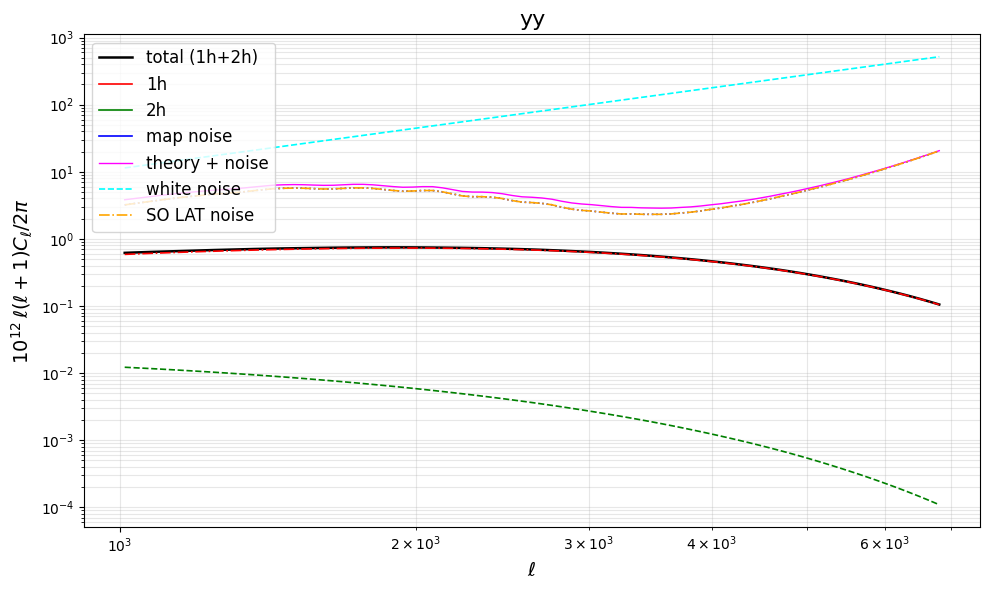

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cl_yy.png


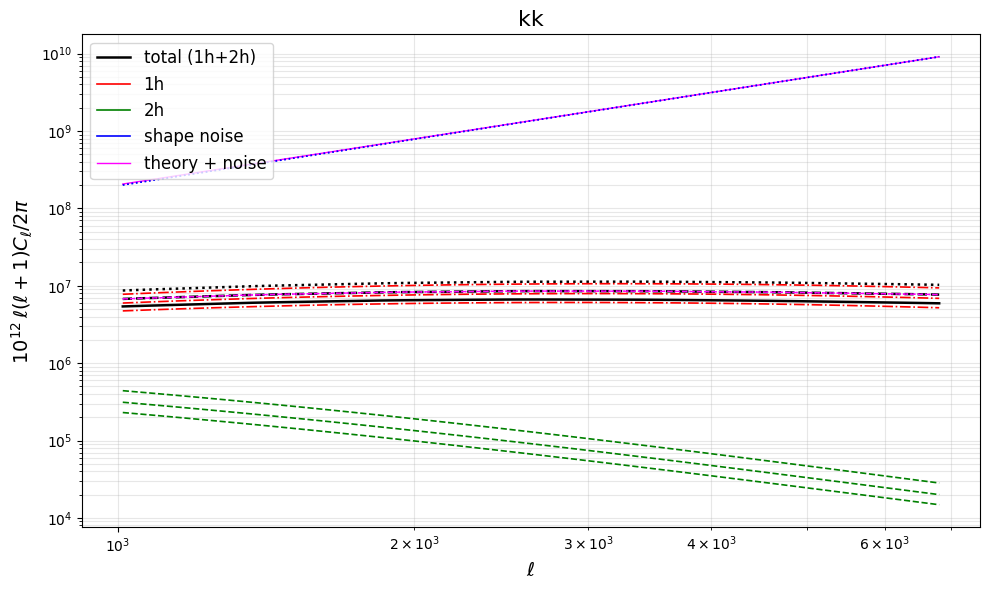

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cl_kk.png


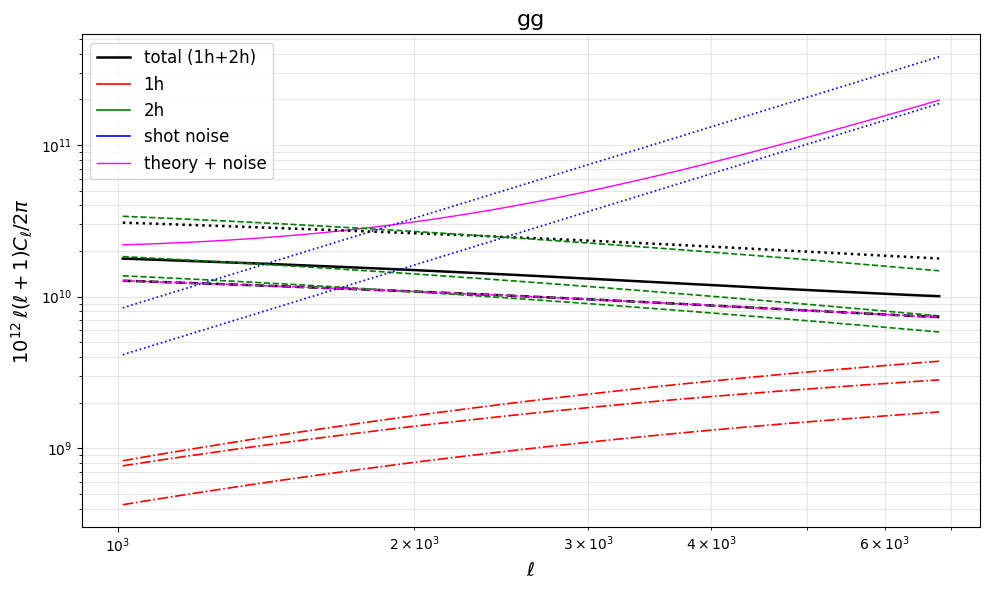

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cl_gg.png


In [23]:
ell = np.array(analysis_dict['l_array_survey'])
Nl_white = make_yy_white_noise_file(ell,fname='../../../tests/mock-data/yy-white-noise.txt',
    N0_y2sr=7e-17,   # override with a specific value if needed
    debeam=False,      # GODMAX already applies B_l^2 to signal → keep flat
)

SO_noise_data = np.loadtxt('/home/vtinnane/Documents/Codes/develop/tSZxEuclid/Data/SO_LAT_Nell_T_atmv1_baseline_fsky0p4_ILC_tSZ.txt')
SO_ell = SO_noise_data[:,0]
SO_noise = SO_noise_data[:,1]
#interp SO noise to ell
Nl_so_interp = interp1d(SO_ell, SO_noise, bounds_error=False, fill_value=np.inf)
Nl_so = Nl_so_interp(ell)
yy_noises = [
    {
        "ell": ell,
        "cl": Nl_white,
        "label": "white noise",
        "color": "cyan",
        "ls": "--",
        "lw": 1.2,
    },
    {
        "ell": ell,
        "cl": Nl_so,
        "label": "SO LAT noise",
        "color": "orange",
        "ls": "-.",
        "lw": 1.2,
    },
]

abs_path_results = "/home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/"

plot_cl_per_probe(
    get_cl=get_cl,
    cov_obj=cov_old,
    results_path=abs_path_results,
    probes_to_show=("yy", "kk", "gg"),
    yy_extra_noises=yy_noises,
)

In [24]:
def check_full_field_psd_ky_gy(cov_obj):
    ky_bins = [bc[0] for bc in cov_obj.Cl_result_dict["ky"]["bin_combs"]]   # source bins, 1-based
    gy_bins = [bc[0] for bc in cov_obj.Cl_result_dict["gy"]["bin_combs"]]   # lens bins, 1-based

    ky_bins = sorted(set(ky_bins))
    gy_bins = sorted(set(gy_bins))

    Cyy = np.array(cov_obj.Cl_result_dict["yy"]["bin_0_0"]["tot_plus_noise_ellsurvey"], float)
    nell = len(Cyy)

    min_eigs = []

    for ell_idx in range(nell):
        nfield = len(ky_bins) + len(gy_bins) + 1
        S = np.zeros((nfield, nfield), dtype=float)

        # k-k block
        for a, sb1 in enumerate(ky_bins):
            for b, sb2 in enumerate(ky_bins):
                key = f"bin_{sb1}_{sb2}"
                S[a, b] = cov_obj.Cl_result_dict["kk"][key]["tot_plus_noise_ellsurvey"][ell_idx]

        # g-g block
        offset_g = len(ky_bins)
        for a, lb1 in enumerate(gy_bins):
            for b, lb2 in enumerate(gy_bins):
                key = f"bin_{lb1}_{lb2}"
                S[offset_g + a, offset_g + b] = cov_obj.Cl_result_dict["gg"][key]["tot_plus_noise_ellsurvey"][ell_idx]

        # k-g block from gk
        for a, sb in enumerate(ky_bins):
            for b, lb in enumerate(gy_bins):
                key = f"bin_{lb}_{sb}"
                val = cov_obj.Cl_result_dict["gk"][key]["tot_ellsurvey"][ell_idx]
                S[a, offset_g + b] = val
                S[offset_g + b, a] = val

        # k-y block
        idx_y = nfield - 1
        for a, sb in enumerate(ky_bins):
            val = cov_obj.Cl_result_dict["ky"][f"bin_{sb}_0"]["tot_ellsurvey"][ell_idx]
            S[a, idx_y] = val
            S[idx_y, a] = val

        # g-y block
        for b, lb in enumerate(gy_bins):
            val = cov_obj.Cl_result_dict["gy"][f"bin_{lb}_0"]["tot_ellsurvey"][ell_idx]
            S[offset_g + b, idx_y] = val
            S[idx_y, offset_g + b] = val

        # y-y
        S[idx_y, idx_y] = Cyy[ell_idx]

        ev = np.linalg.eigvalsh(0.5 * (S + S.T))
        min_eigs.append(ev.min())

    return np.array(min_eigs)

min_eigs_full = check_full_field_psd_ky_gy(cov_old)
print(min_eigs_full.min())

min_eigs_full = check_full_field_psd_ky_gy(cov_old)
worst_ell_idx = np.argmin(min_eigs_full)
print("worst ell index =", worst_ell_idx)
print("min eigenvalue  =", min_eigs_full[worst_ell_idx])
print("ell value       =", cov_old.Cl_result_dict["l_array_survey"][worst_ell_idx])

def get_full_field_matrix_ky_gy(cov_obj, ell_idx):
    ky_bins = sorted(set(bc[0] for bc in cov_obj.Cl_result_dict["ky"]["bin_combs"]))
    gy_bins = sorted(set(bc[0] for bc in cov_obj.Cl_result_dict["gy"]["bin_combs"]))

    Cyy = np.array(cov_obj.Cl_result_dict["yy"]["bin_0_0"]["tot_plus_noise_ellsurvey"], float)

    nfield = len(ky_bins) + len(gy_bins) + 1
    S = np.zeros((nfield, nfield), dtype=float)
    labels = []

    for sb in ky_bins:
        labels.append(f"k{sb}")
    for lb in gy_bins:
        labels.append(f"g{lb}")
    labels.append("y")

    # kk
    for a, sb1 in enumerate(ky_bins):
        for b, sb2 in enumerate(ky_bins):
            S[a, b] = cov_obj.Cl_result_dict["kk"][f"bin_{sb1}_{sb2}"]["tot_plus_noise_ellsurvey"][ell_idx]

    # gg
    off = len(ky_bins)
    for a, lb1 in enumerate(gy_bins):
        for b, lb2 in enumerate(gy_bins):
            S[off+a, off+b] = cov_obj.Cl_result_dict["gg"][f"bin_{lb1}_{lb2}"]["tot_plus_noise_ellsurvey"][ell_idx]

    # gk
    for a, sb in enumerate(ky_bins):
        for b, lb in enumerate(gy_bins):
            val = cov_obj.Cl_result_dict["gk"][f"bin_{lb}_{sb}"]["tot_ellsurvey"][ell_idx]
            S[a, off+b] = val
            S[off+b, a] = val

    # ky
    iy = nfield - 1
    for a, sb in enumerate(ky_bins):
        val = cov_obj.Cl_result_dict["ky"][f"bin_{sb}_0"]["tot_ellsurvey"][ell_idx]
        S[a, iy] = val
        S[iy, a] = val

    # gy
    for b, lb in enumerate(gy_bins):
        val = cov_obj.Cl_result_dict["gy"][f"bin_{lb}_0"]["tot_ellsurvey"][ell_idx]
        S[off+b, iy] = val
        S[iy, off+b] = val

    # yy
    S[iy, iy] = Cyy[ell_idx]

    return 0.5*(S+S.T), labels

S, labels = get_full_field_matrix_ky_gy(cov_old, worst_ell_idx)
evals, evecs = np.linalg.eigh(S)
print("min eval:", evals[0])
for lab, coeff in zip(labels, evecs[:, 0]):
    print(f"{lab:>4s}  {coeff:+.4e}")

def check_y_schur_ky_gy(cov_obj, ell_idx):
    ky_bins = sorted(set(bc[0] for bc in cov_obj.Cl_result_dict["ky"]["bin_combs"]))
    gy_bins = sorted(set(bc[0] for bc in cov_obj.Cl_result_dict["gy"]["bin_combs"]))

    nk = len(ky_bins)
    ng = len(gy_bins)
    nkg = nk + ng

    A = np.zeros((nkg, nkg), dtype=float)
    b = np.zeros(nkg, dtype=float)

    # kk block
    for a, sb1 in enumerate(ky_bins):
        for c, sb2 in enumerate(ky_bins):
            A[a, c] = cov_obj.Cl_result_dict["kk"][f"bin_{sb1}_{sb2}"]["tot_plus_noise_ellsurvey"][ell_idx]

    # gg block
    off = nk
    for a, lb1 in enumerate(gy_bins):
        for c, lb2 in enumerate(gy_bins):
            A[off+a, off+c] = cov_obj.Cl_result_dict["gg"][f"bin_{lb1}_{lb2}"]["tot_plus_noise_ellsurvey"][ell_idx]

    # gk block
    for a, sb in enumerate(ky_bins):
        for c, lb in enumerate(gy_bins):
            val = cov_obj.Cl_result_dict["gk"][f"bin_{lb}_{sb}"]["tot_ellsurvey"][ell_idx]
            A[a, off+c] = val
            A[off+c, a] = val

    # ky entries
    for a, sb in enumerate(ky_bins):
        b[a] = cov_obj.Cl_result_dict["ky"][f"bin_{sb}_0"]["tot_ellsurvey"][ell_idx]

    # gy entries
    for c, lb in enumerate(gy_bins):
        b[off+c] = cov_obj.Cl_result_dict["gy"][f"bin_{lb}_0"]["tot_ellsurvey"][ell_idx]

    Cyy = cov_obj.Cl_result_dict["yy"]["bin_0_0"]["tot_plus_noise_ellsurvey"][ell_idx]

    schur = Cyy - b @ np.linalg.pinv(A) @ b
    return schur, Cyy, b, A

schur, Cyy, b, A = check_y_schur_ky_gy(cov_old, 154)
print("Schur complement =", schur)
print("Cyy =", Cyy)
print("b^T A^+ b =", Cyy - schur)


-2.1295943050444077e-19
worst ell index = 46
min eigenvalue  = -2.1295943050444077e-19
ell value       = 2949.360399931806
min eval: -2.1295943050443153e-19
  k1  +1.3582e-05
  k2  +1.9284e-05
  g1  -8.2088e-06
  g2  -3.0100e-06
   y  +1.0000e+00
Schur complement = 2.737793936872662e-18
Cyy = 2.7898816505406545e-18
b^T A^+ b = 5.2087713667992296e-20



Probes: ['kk']   [kk]
  kk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]

  Full ordering:
    00: ('kk', (1, 1))
    01: ('kk', (1, 2))
    02: ('kk', (2, 2))

  Matrix size : (324, 324)
  Max asymm.  : 0.000e+00
  Min diag    : 1.793e-22
  Max diag    : 1.636e-19
  Eigen min   : 1.787e-22
  Eigen max   : 2.300e-19
  Neg eigvals : 0 / 324
  Condition # : 1.287e+03
  log|det|    : -15188.726  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


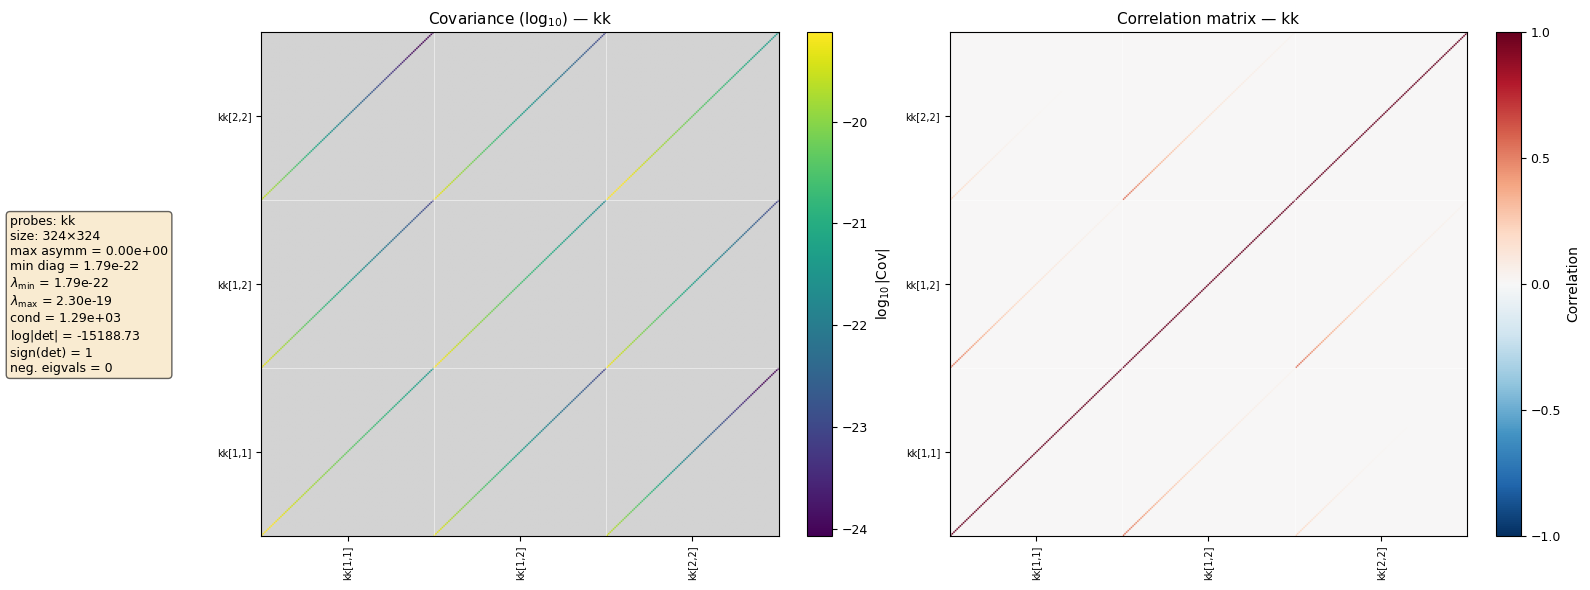

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_kk.png

Probes: ['gg']   [gg]
  gg bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]

  Full ordering:
    00: ('gg', (1, 1))
    01: ('gg', (1, 2))
    02: ('gg', (2, 2))

  Matrix size : (324, 324)
  Max asymm.  : 0.000e+00
  Min diag    : 2.344e-18
  Max diag    : 7.424e-12
  Eigen min   : 7.859e-19
  Eigen max   : 1.014e-11
  Neg eigvals : 0 / 324
  Condition # : 1.291e+07
  log|det|    : -10797.930  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


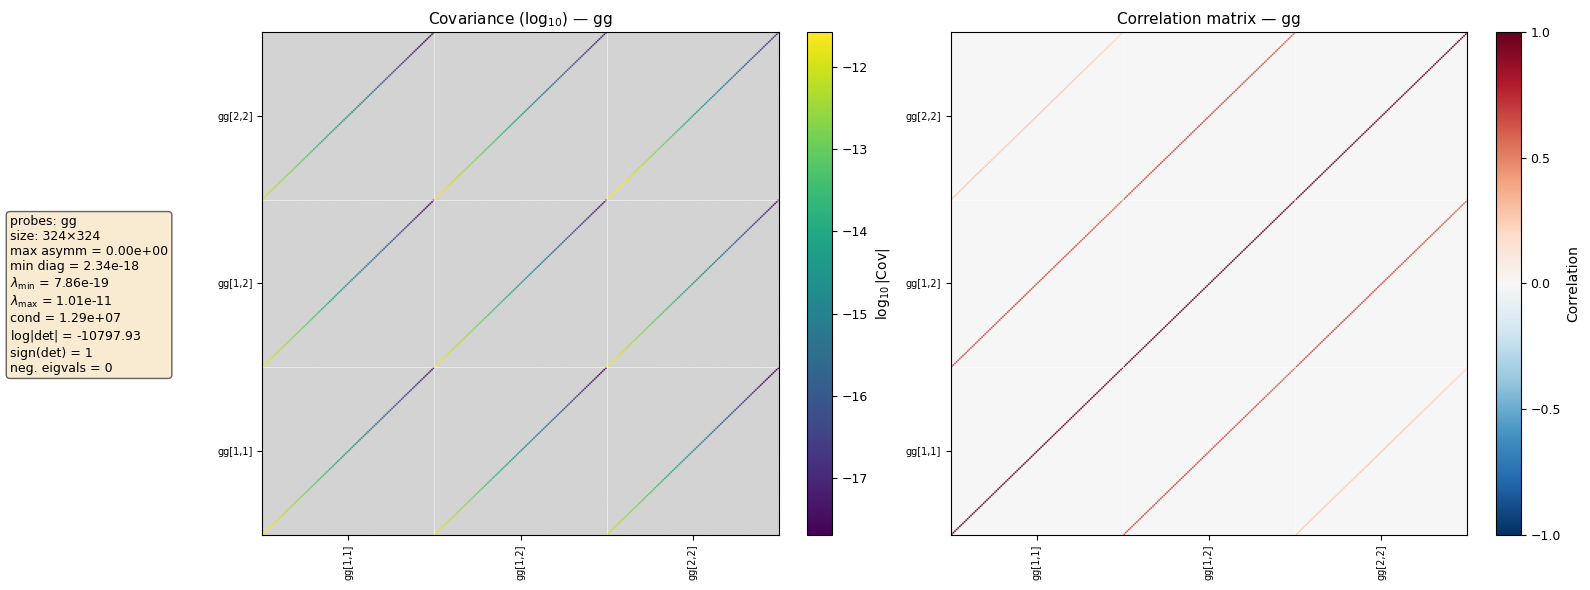

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_gg.png

Probes: ['yy']   [yy]
  yy bin_combs: [[0, 0]]

  Full ordering:
    00: ('yy', (0, 0))

  Matrix size : (108, 108)
  Max asymm.  : 0.000e+00
  Min diag    : 6.438e-38
  Max diag    : 1.126e-33
  Eigen min   : 6.438e-38
  Eigen max   : 1.126e-33
  Neg eigvals : 0 / 108
  Condition # : 1.749e+04
  log|det|    : -8766.978  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


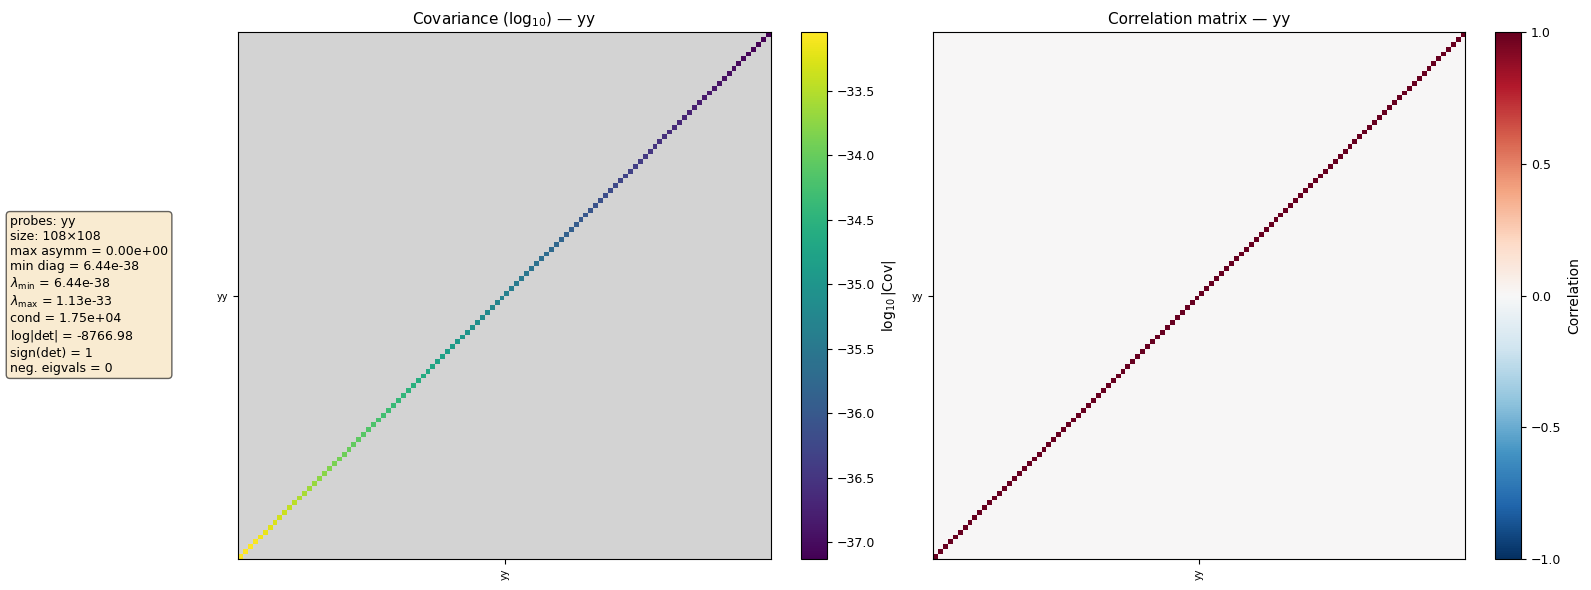

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_yy.png

Probes: ['gy']   [gy]
  gy bin_combs: [[1, 0], [2, 0]]

  Full ordering:
    00: ('gy', (1, 0))
    01: ('gy', (2, 0))

  Matrix size : (216, 216)
  Max asymm.  : 0.000e+00
  Min diag    : 2.805e-28
  Max diag    : 5.311e-23
  Eigen min   : 1.616e-28
  Eigen max   : 7.062e-23
  Neg eigvals : 0 / 216
  Condition # : 4.370e+05
  log|det|    : -12451.271  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


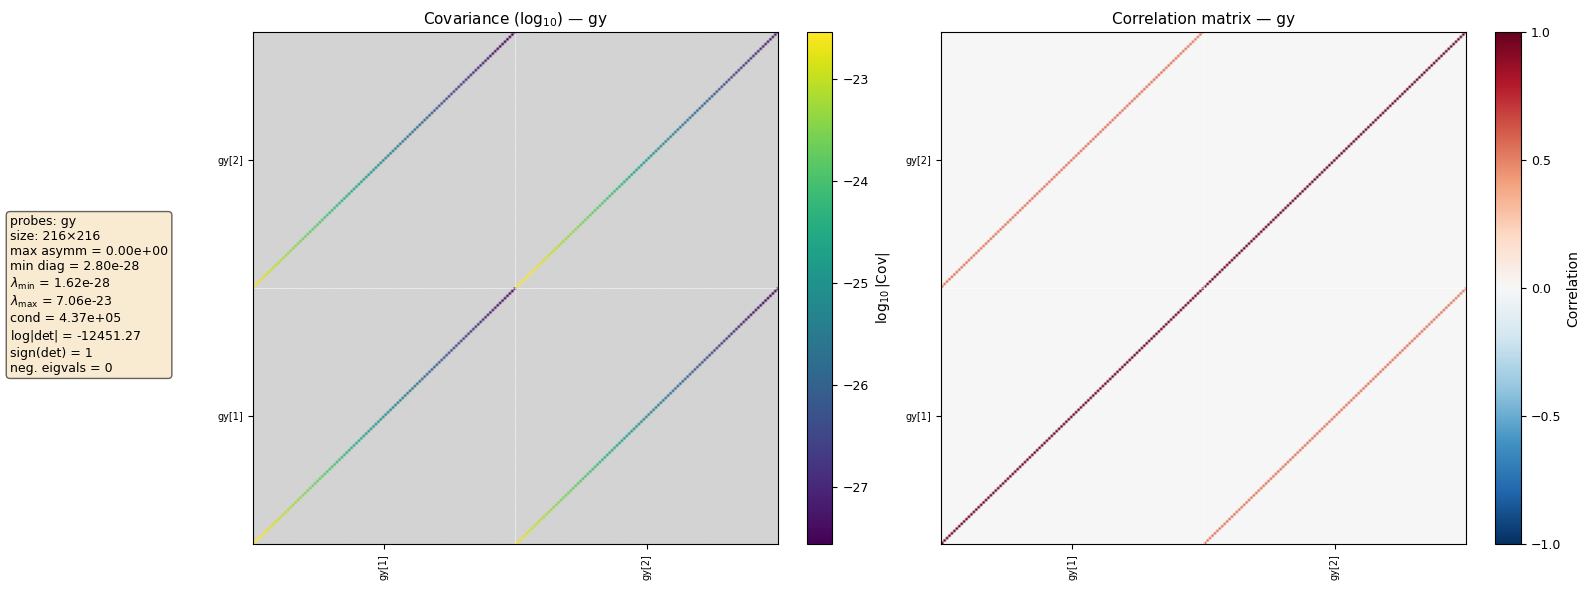

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_gy.png

Probes: ['ky']   [ky]
  ky bin_combs: [[1, 0], [2, 0]]

  Full ordering:
    00: ('ky', (1, 0))
    01: ('ky', (2, 0))

  Matrix size : (216, 216)
  Max asymm.  : 0.000e+00
  Min diag    : 1.722e-30
  Max diag    : 6.500e-27
  Eigen min   : 1.663e-30
  Eigen max   : 9.173e-27
  Neg eigvals : 0 / 216
  Condition # : 5.515e+03
  log|det|    : -14008.054  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


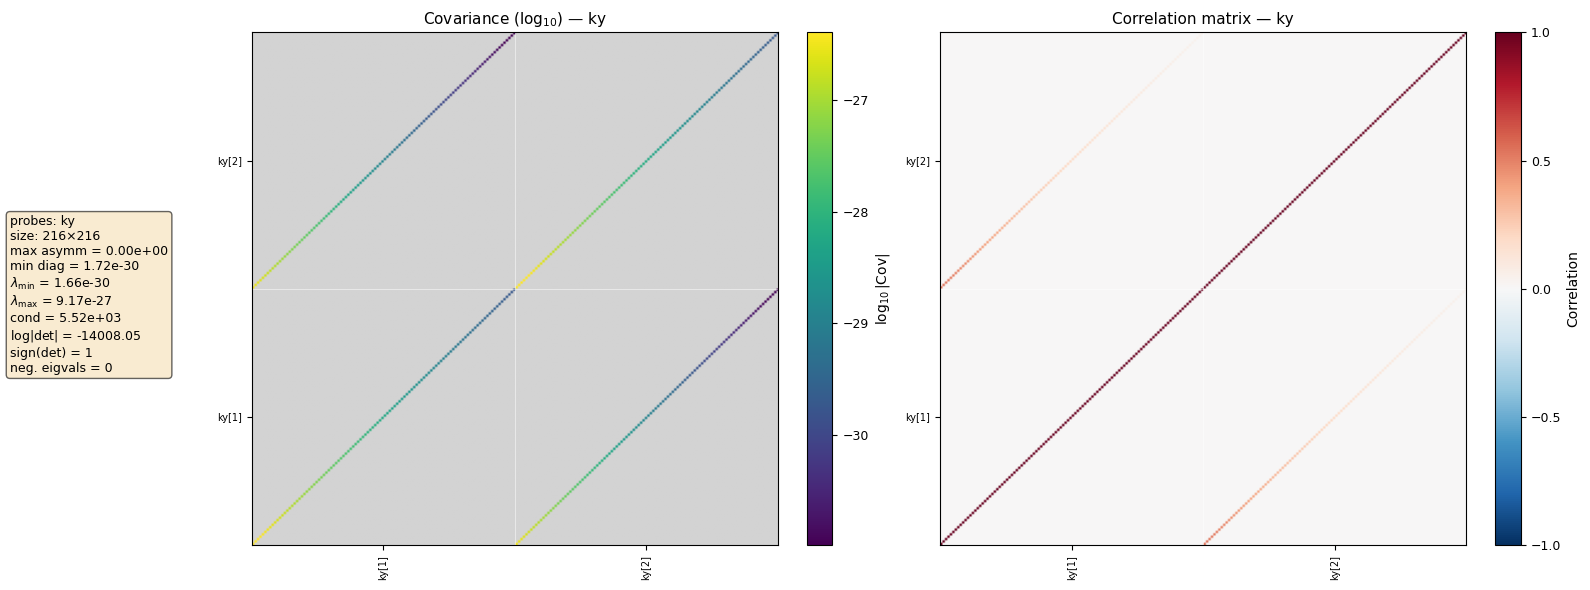

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_ky.png

Probes: ['gk']   [gk]
  gk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]

  Full ordering:
    00: ('gk', (1, 1))
    01: ('gk', (1, 2))
    02: ('gk', (2, 1))
    03: ('gk', (2, 2))

  Matrix size : (432, 432)
  Max asymm.  : 0.000e+00
  Min diag    : 1.396e-20
  Max diag    : 6.329e-16
  Eigen min   : 7.844e-21
  Eigen max   : 1.318e-15
  Neg eigvals : 0 / 432
  Condition # : 1.680e+05
  log|det|    : -17550.635  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


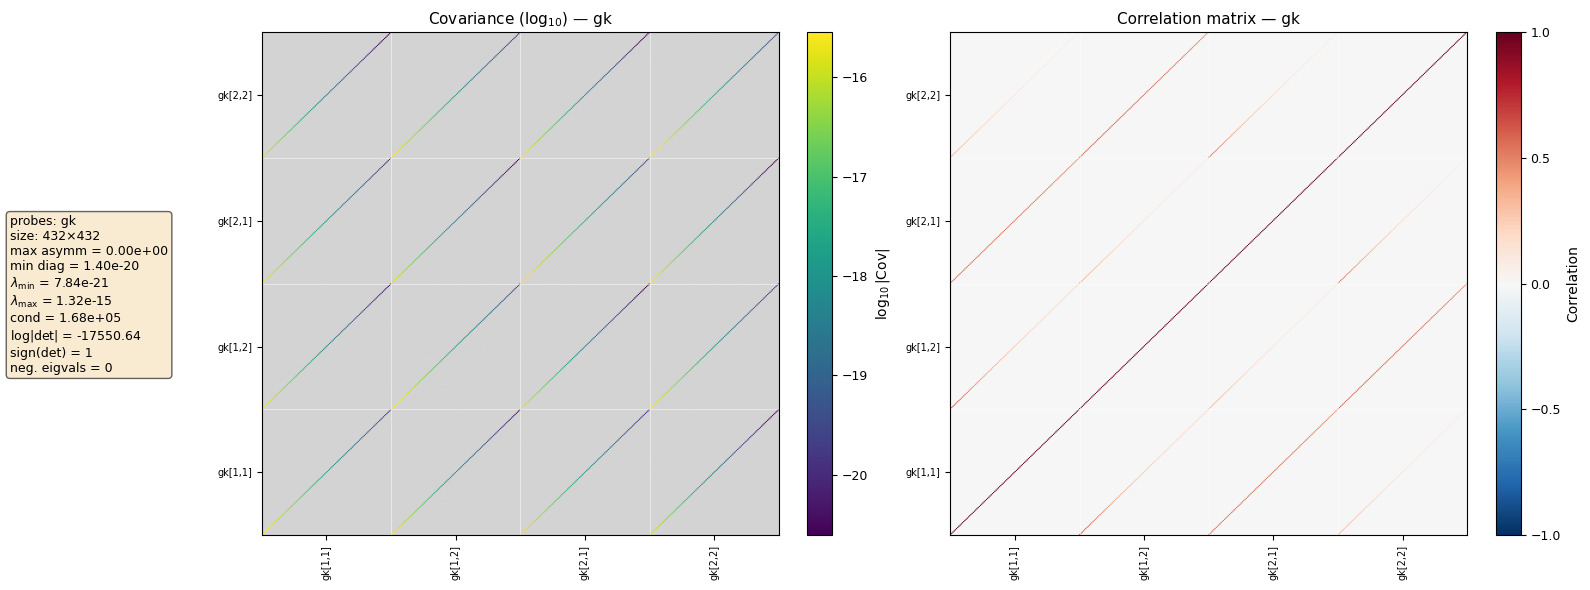

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_gk.png

Probes: ['kk', 'gk']   [kk_gk]
  kk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]

  Full ordering:
    00: ('kk', (1, 1))
    01: ('kk', (1, 2))
    02: ('kk', (2, 2))
    03: ('gk', (1, 1))
    04: ('gk', (1, 2))
    05: ('gk', (2, 1))
    06: ('gk', (2, 2))

  Matrix size : (756, 756)
  Max asymm.  : 0.000e+00
  Min diag    : 1.793e-22
  Max diag    : 6.329e-16
  Eigen min   : 1.410e-22
  Eigen max   : 1.318e-15
  Neg eigvals : 0 / 756
  Condition # : 9.346e+06
  log|det|    : -32804.590  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


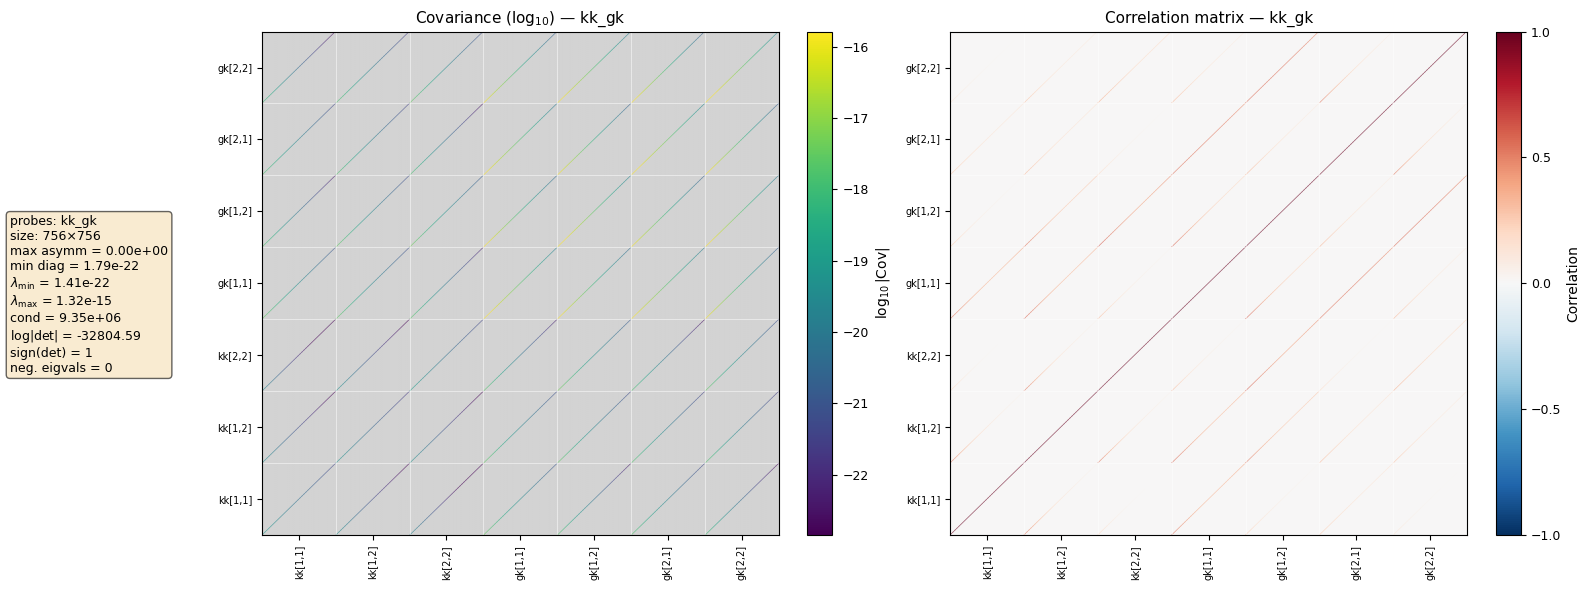

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_kk_gk.png

Probes: ['kk', 'gy']   [kk_gy]
  kk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gy bin_combs: [[1, 0], [2, 0]]

  Full ordering:
    00: ('kk', (1, 1))
    01: ('kk', (1, 2))
    02: ('kk', (2, 2))
    03: ('gy', (1, 0))
    04: ('gy', (2, 0))

  Matrix size : (540, 540)
  Max asymm.  : 0.000e+00
  Min diag    : 2.805e-28
  Max diag    : 1.636e-19
  Eigen min   : 1.615e-28
  Eigen max   : 2.300e-19
  Neg eigvals : 0 / 540
  Condition # : 1.424e+09
  log|det|    : -27641.375  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


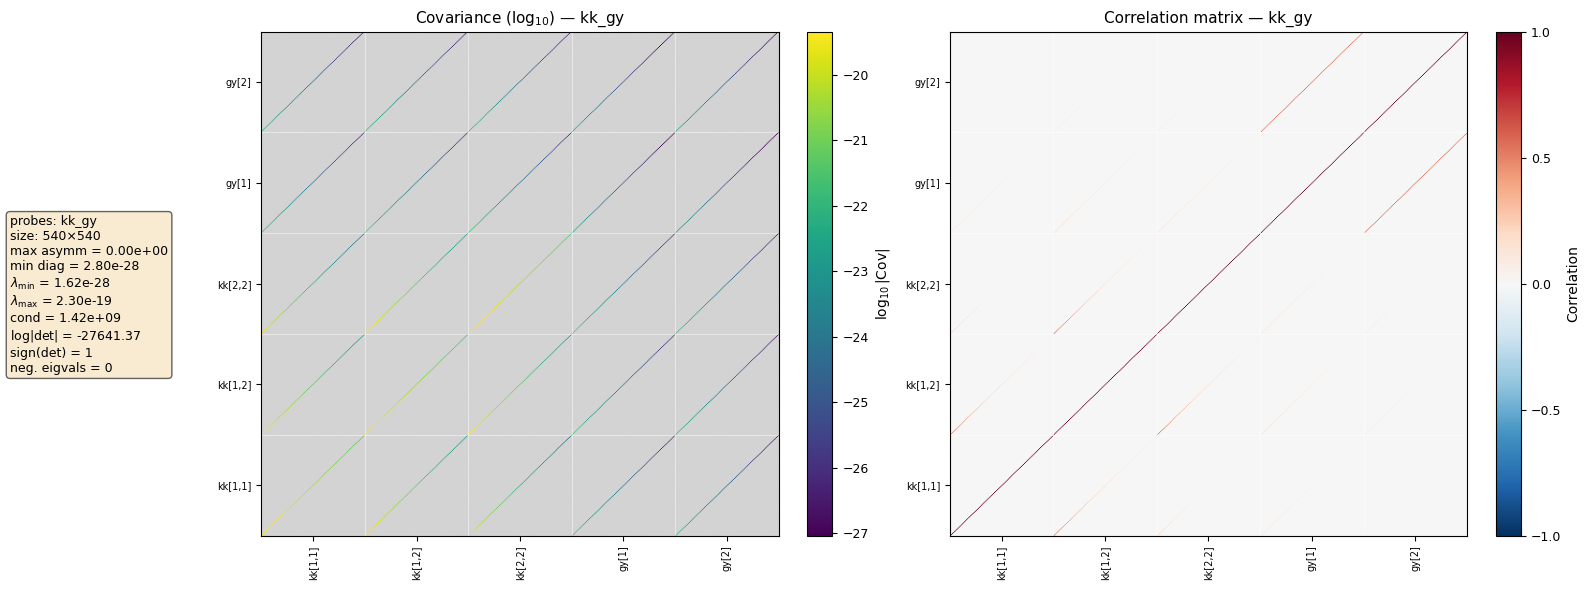

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_kk_gy.png

Probes: ['kk', 'ky']   [kk_ky]
  kk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  ky bin_combs: [[1, 0], [2, 0]]

  Full ordering:
    00: ('kk', (1, 1))
    01: ('kk', (1, 2))
    02: ('kk', (2, 2))
    03: ('ky', (1, 0))
    04: ('ky', (2, 0))

  Matrix size : (540, 540)
  Max asymm.  : 0.000e+00
  Min diag    : 1.722e-30
  Max diag    : 1.636e-19
  Eigen min   : 1.661e-30
  Eigen max   : 2.300e-19
  Neg eigvals : 0 / 540
  Condition # : 1.385e+11
  log|det|    : -29203.644  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


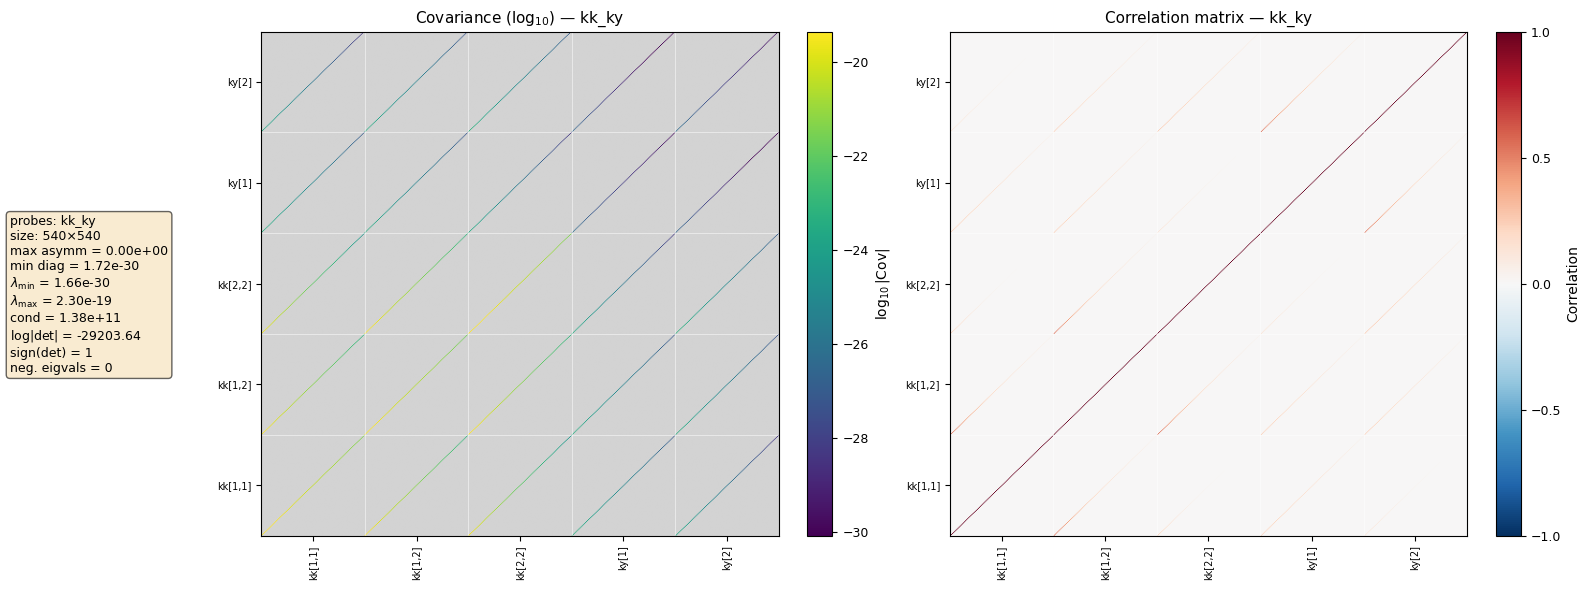

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_kk_ky.png

Probes: ['kk', 'gg']   [kk_gg]
  kk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gg bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]

  Full ordering:
    00: ('kk', (1, 1))
    01: ('kk', (1, 2))
    02: ('kk', (2, 2))
    03: ('gg', (1, 1))
    04: ('gg', (1, 2))
    05: ('gg', (2, 2))

  Matrix size : (648, 648)
  Max asymm.  : 0.000e+00
  Min diag    : 1.793e-22
  Max diag    : 7.424e-12
  Eigen min   : 1.700e-22
  Eigen max   : 1.014e-11
  Neg eigvals : 0 / 648
  Condition # : 5.967e+10
  log|det|    : -25994.122  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


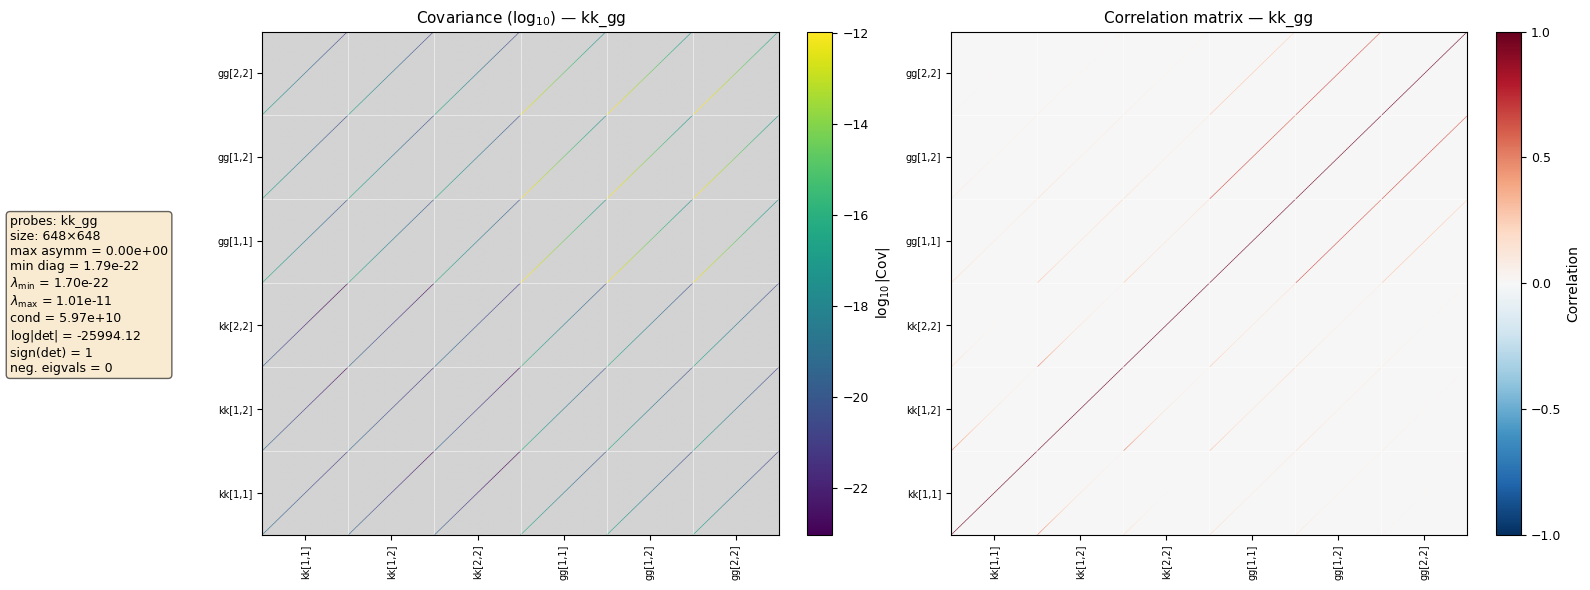

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_kk_gg.png

Probes: ['kk', 'yy']   [kk_yy]
  kk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  yy bin_combs: [[0, 0]]

  Full ordering:
    00: ('kk', (1, 1))
    01: ('kk', (1, 2))
    02: ('kk', (2, 2))
    03: ('yy', (0, 0))

  Matrix size : (432, 432)
  Max asymm.  : 0.000e+00
  Min diag    : 6.438e-38
  Max diag    : 1.636e-19
  Eigen min   : 6.438e-38
  Eigen max   : 2.300e-19
  Neg eigvals : 0 / 432
  Condition # : 3.573e+18
  log|det|    : -23955.802  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


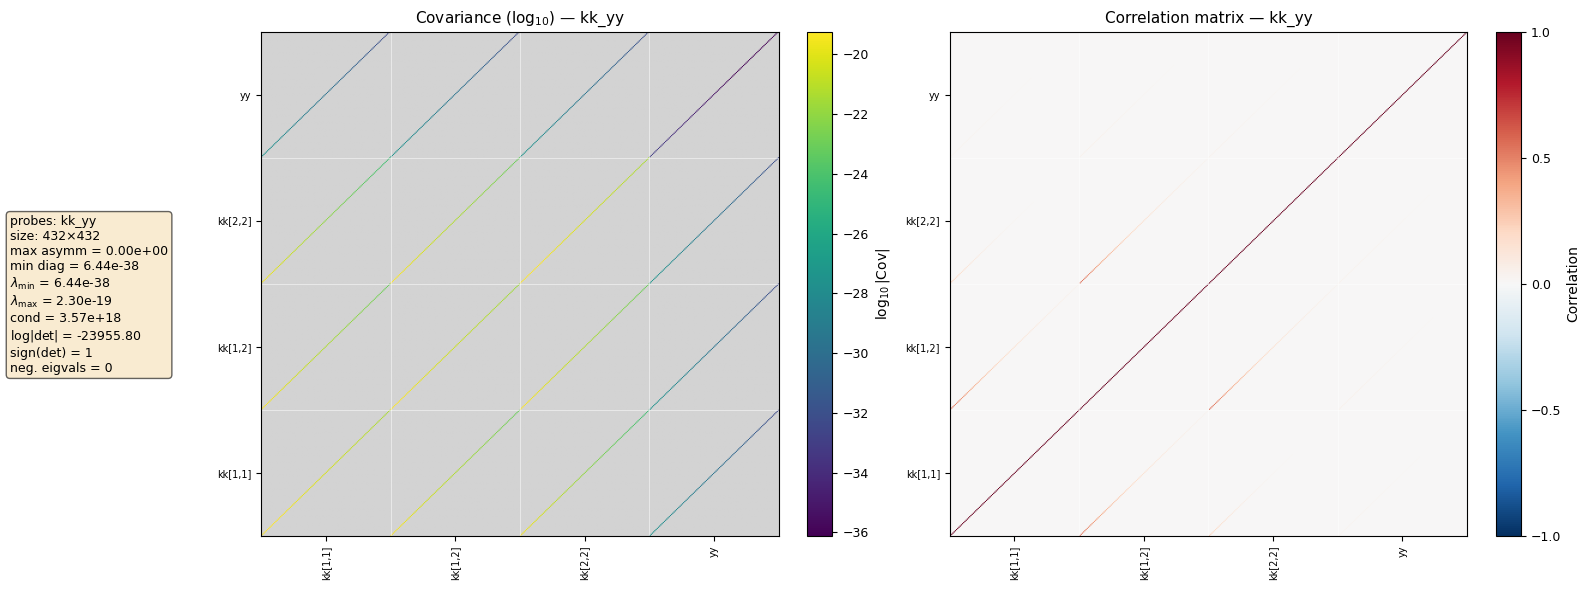

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_kk_yy.png

Probes: ['gk', 'gg']   [gk_gg]
  gk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gg bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]

  Full ordering:
    00: ('gk', (1, 1))
    01: ('gk', (1, 2))
    02: ('gk', (2, 1))
    03: ('gk', (2, 2))
    04: ('gg', (1, 1))
    05: ('gg', (1, 2))
    06: ('gg', (2, 2))

  Matrix size : (756, 756)
  Max asymm.  : 0.000e+00
  Min diag    : 1.396e-20
  Max diag    : 7.424e-12
  Eigen min   : 4.749e-21
  Eigen max   : 1.014e-11
  Neg eigvals : 0 / 756
  Condition # : 2.136e+09
  log|det|    : -28456.909  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


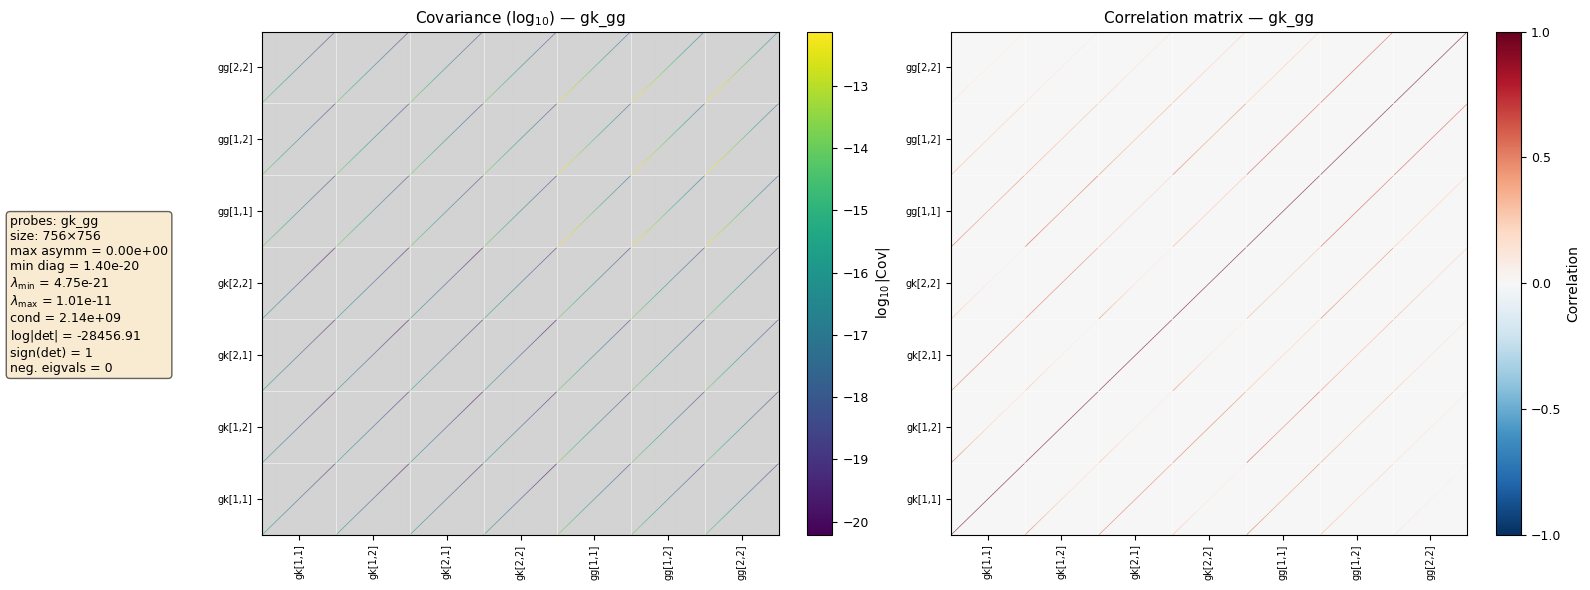

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_gk_gg.png

Probes: ['gy', 'gg']   [gy_gg]
  gy bin_combs: [[1, 0], [2, 0]]
  gg bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]

  Full ordering:
    00: ('gy', (1, 0))
    01: ('gy', (2, 0))
    02: ('gg', (1, 1))
    03: ('gg', (1, 2))
    04: ('gg', (2, 2))

  Matrix size : (540, 540)
  Max asymm.  : 0.000e+00
  Min diag    : 2.805e-28
  Max diag    : 7.424e-12
  Eigen min   : 1.161e-28
  Eigen max   : 1.014e-11
  Neg eigvals : 0 / 540
  Condition # : 1.082e+17
  log|det|    : -23285.997  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


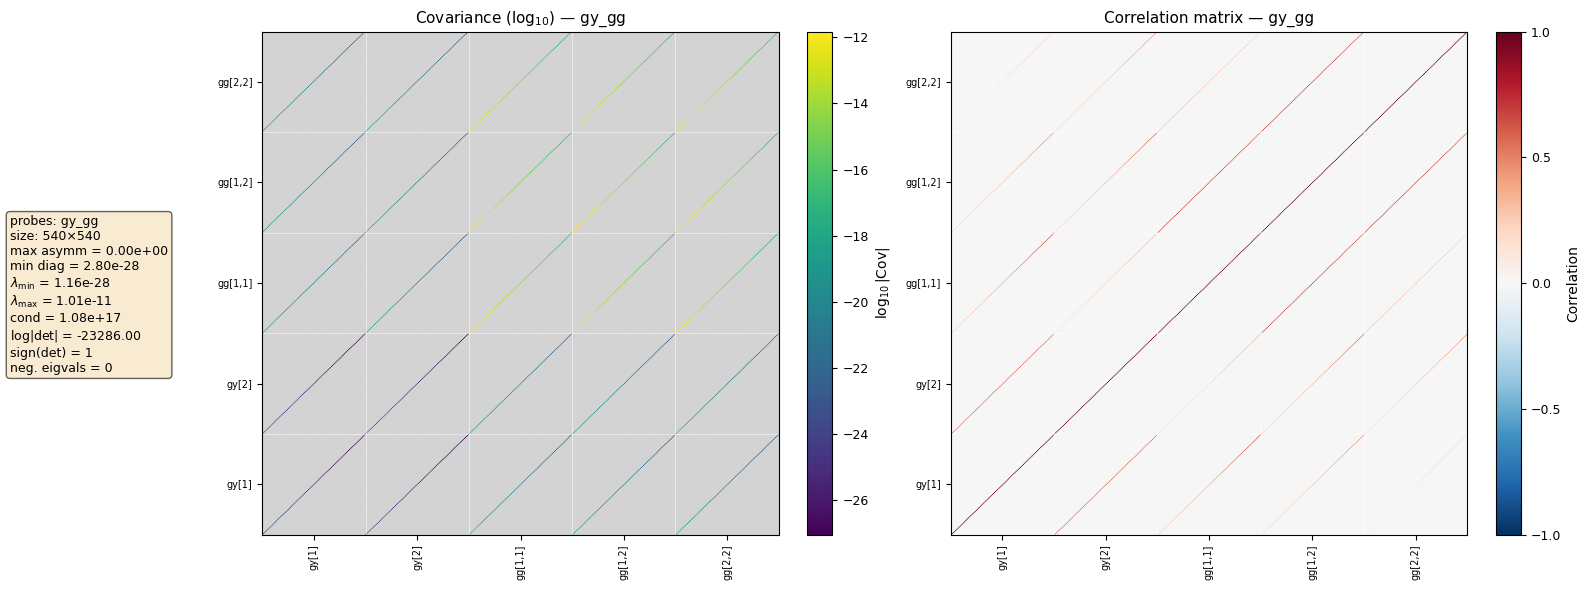

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_gy_gg.png

Probes: ['gg', 'ky']   [gg_ky]
  gg bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  ky bin_combs: [[1, 0], [2, 0]]

  Full ordering:
    00: ('gg', (1, 1))
    01: ('gg', (1, 2))
    02: ('gg', (2, 2))
    03: ('ky', (1, 0))
    04: ('ky', (2, 0))

  Matrix size : (540, 540)
  Max asymm.  : 0.000e+00
  Min diag    : 1.722e-30
  Max diag    : 7.424e-12
  Eigen min   : 1.389e-30
  Eigen max   : 1.014e-11
  Neg eigvals : 0 / 540
  Condition # : 7.301e+18
  log|det|    : -24813.771  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


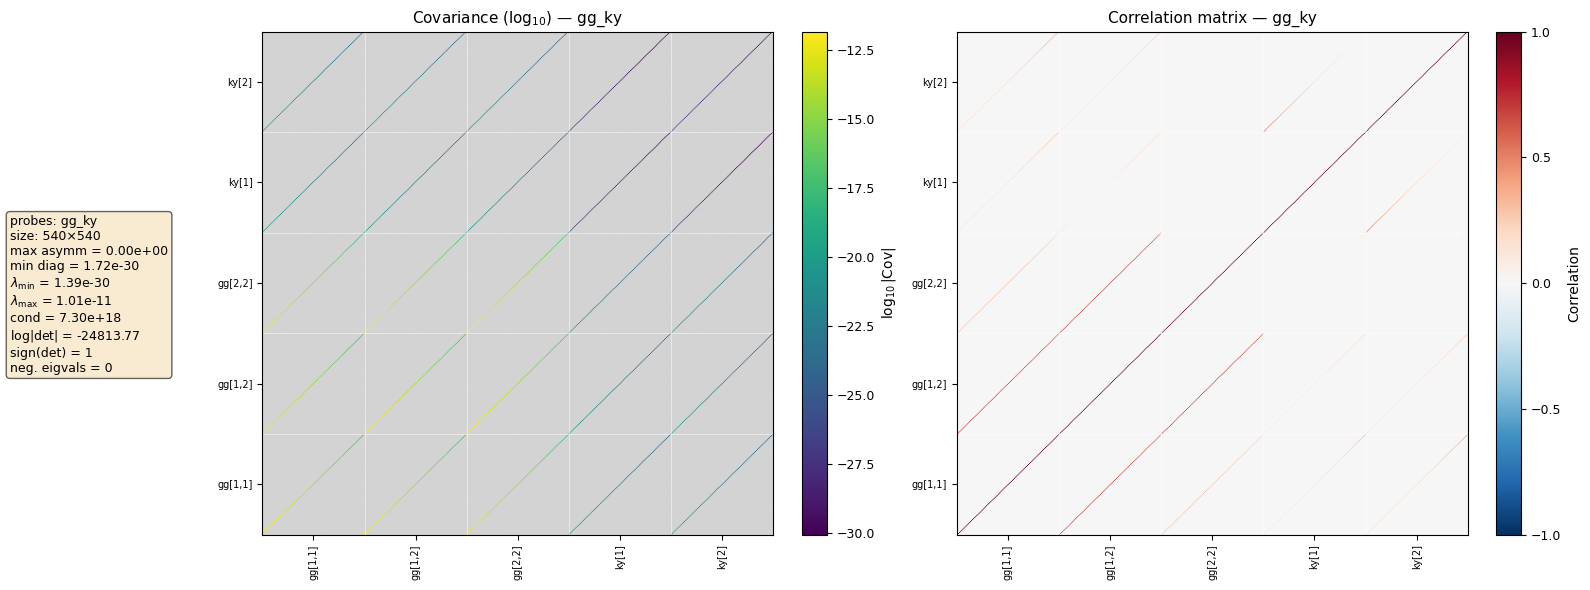

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_gg_ky.png

Probes: ['gg', 'yy']   [gg_yy]
  gg bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  yy bin_combs: [[0, 0]]

  Full ordering:
    00: ('gg', (1, 1))
    01: ('gg', (1, 2))
    02: ('gg', (2, 2))
    03: ('yy', (0, 0))

  Matrix size : (432, 432)
  Max asymm.  : 0.000e+00
  Min diag    : 6.438e-38
  Max diag    : 7.424e-12
  Eigen min   : -7.476e-30
  Eigen max   : 1.014e-11
  Neg eigvals : 5 / 432
  Condition # : 1.708e+26
  log|det|    : -19566.895  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


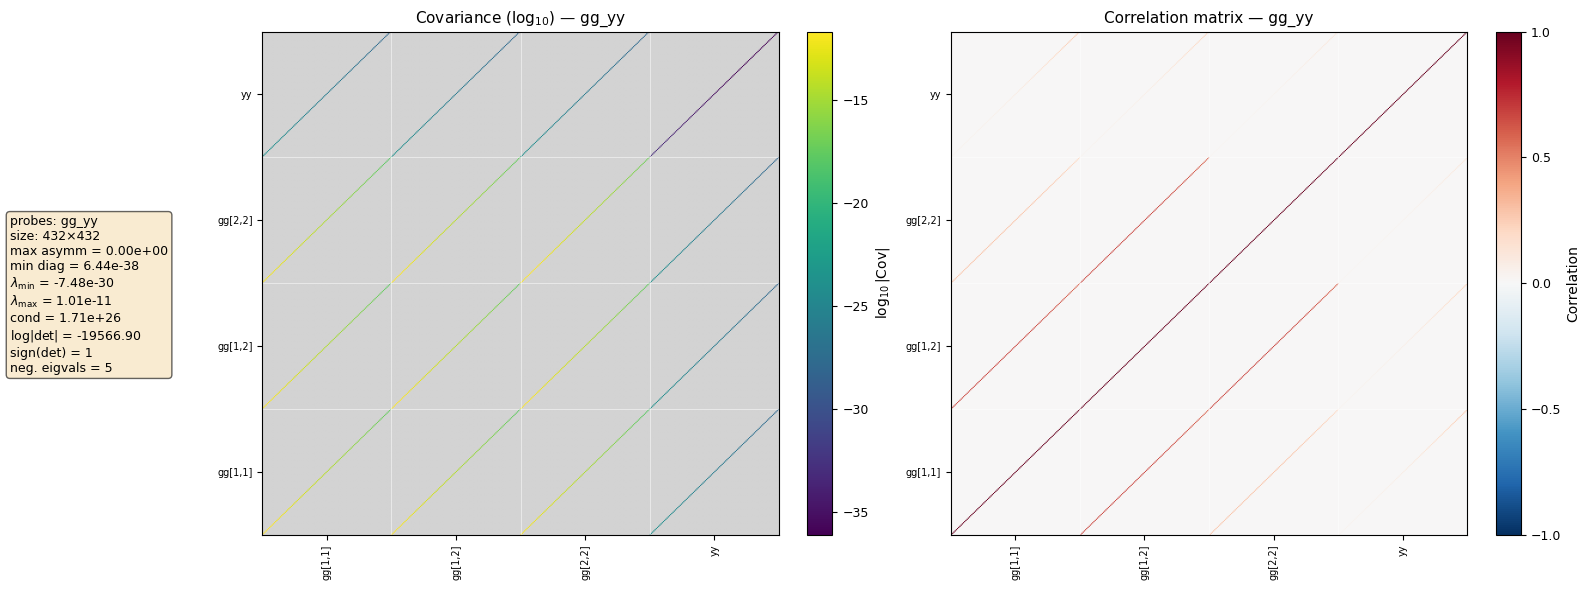

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_gg_yy.png

Probes: ['gy', 'gk']   [gy_gk]
  gy bin_combs: [[1, 0], [2, 0]]
  gk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]

  Full ordering:
    00: ('gy', (1, 0))
    01: ('gy', (2, 0))
    02: ('gk', (1, 1))
    03: ('gk', (1, 2))
    04: ('gk', (2, 1))
    05: ('gk', (2, 2))

  Matrix size : (648, 648)
  Max asymm.  : 0.000e+00
  Min diag    : 2.805e-28
  Max diag    : 6.329e-16
  Eigen min   : 1.535e-28
  Eigen max   : 1.318e-15
  Neg eigvals : 0 / 648
  Condition # : 8.584e+12
  log|det|    : -30013.826  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


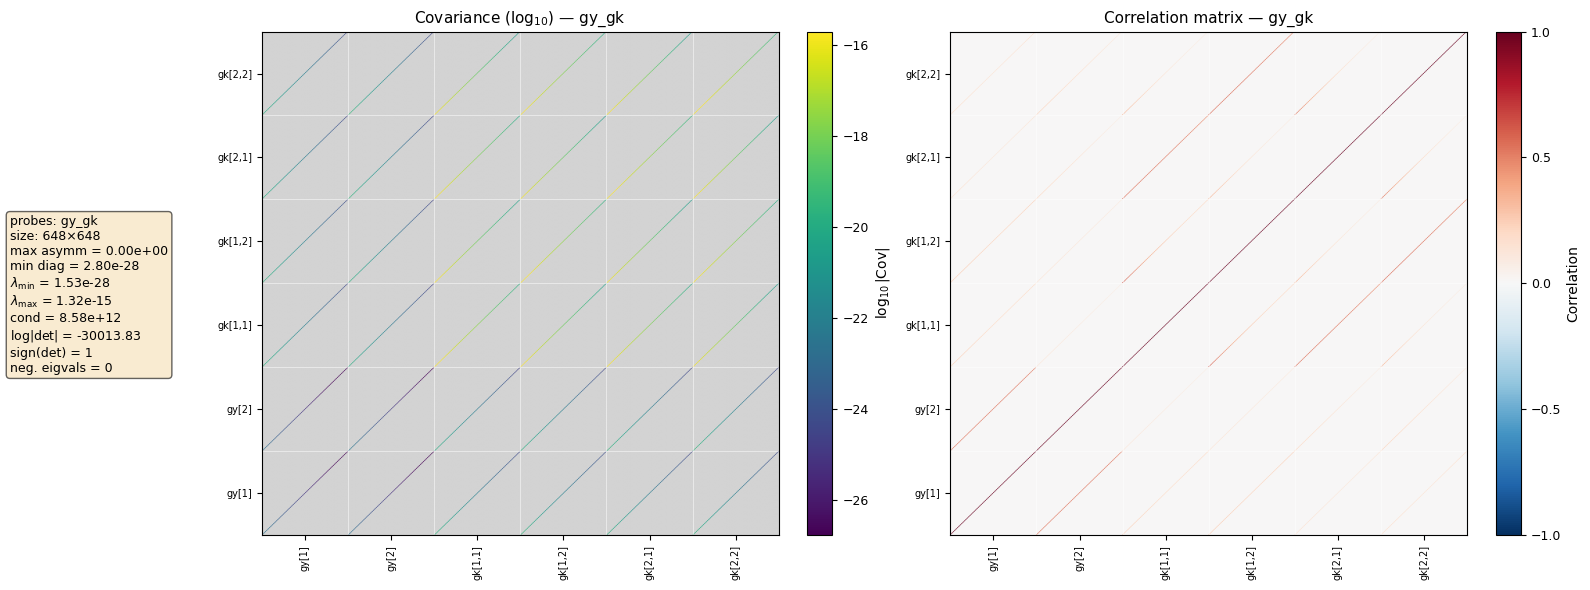

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_gy_gk.png

Probes: ['gg', 'ky']   [gg_ky]
  gg bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  ky bin_combs: [[1, 0], [2, 0]]

  Full ordering:
    00: ('gg', (1, 1))
    01: ('gg', (1, 2))
    02: ('gg', (2, 2))
    03: ('ky', (1, 0))
    04: ('ky', (2, 0))

  Matrix size : (540, 540)
  Max asymm.  : 0.000e+00
  Min diag    : 1.722e-30
  Max diag    : 7.424e-12
  Eigen min   : 1.389e-30
  Eigen max   : 1.014e-11
  Neg eigvals : 0 / 540
  Condition # : 7.301e+18
  log|det|    : -24813.771  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


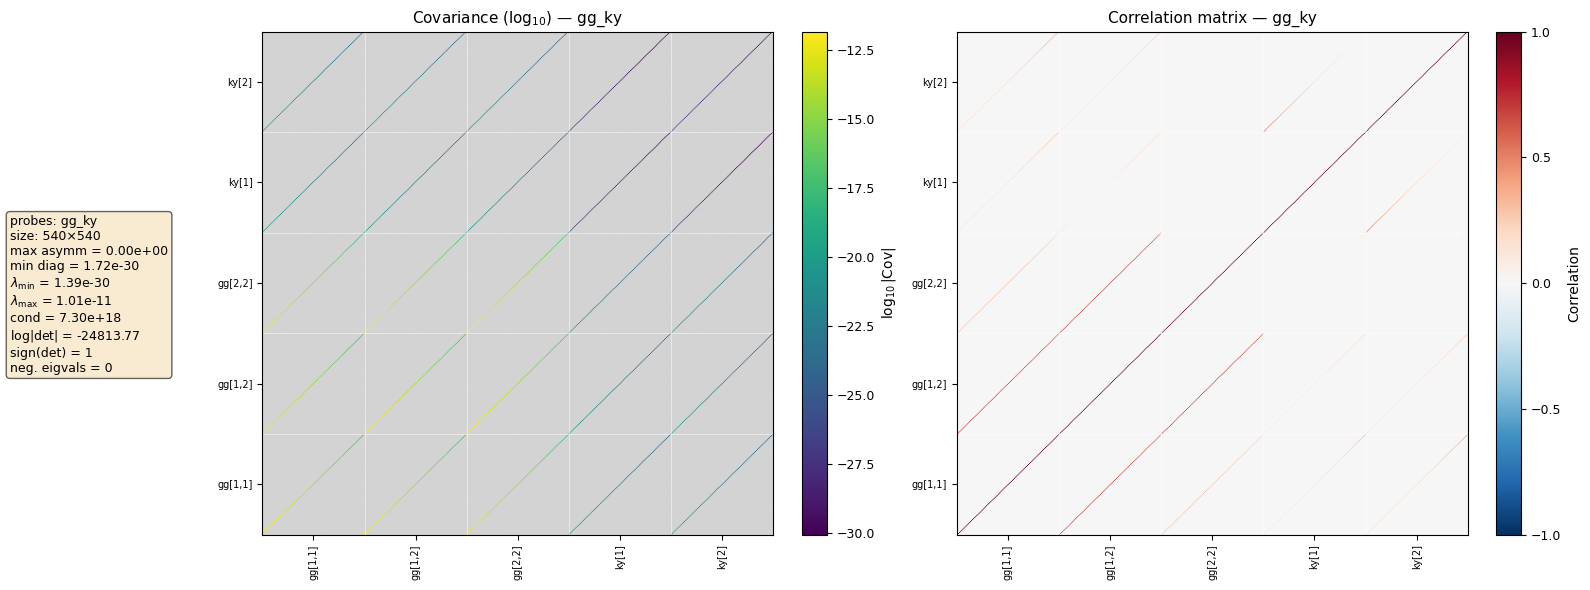

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_gg_ky.png

Probes: ['gk', 'ky']   [gk_ky]
  gk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  ky bin_combs: [[1, 0], [2, 0]]

  Full ordering:
    00: ('gk', (1, 1))
    01: ('gk', (1, 2))
    02: ('gk', (2, 1))
    03: ('gk', (2, 2))
    04: ('ky', (1, 0))
    05: ('ky', (2, 0))

  Matrix size : (648, 648)
  Max asymm.  : 0.000e+00
  Min diag    : 1.722e-30
  Max diag    : 6.329e-16
  Eigen min   : 1.199e-30
  Eigen max   : 1.318e-15
  Neg eigvals : 0 / 648
  Condition # : 1.099e+15
  log|det|    : -31586.106  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


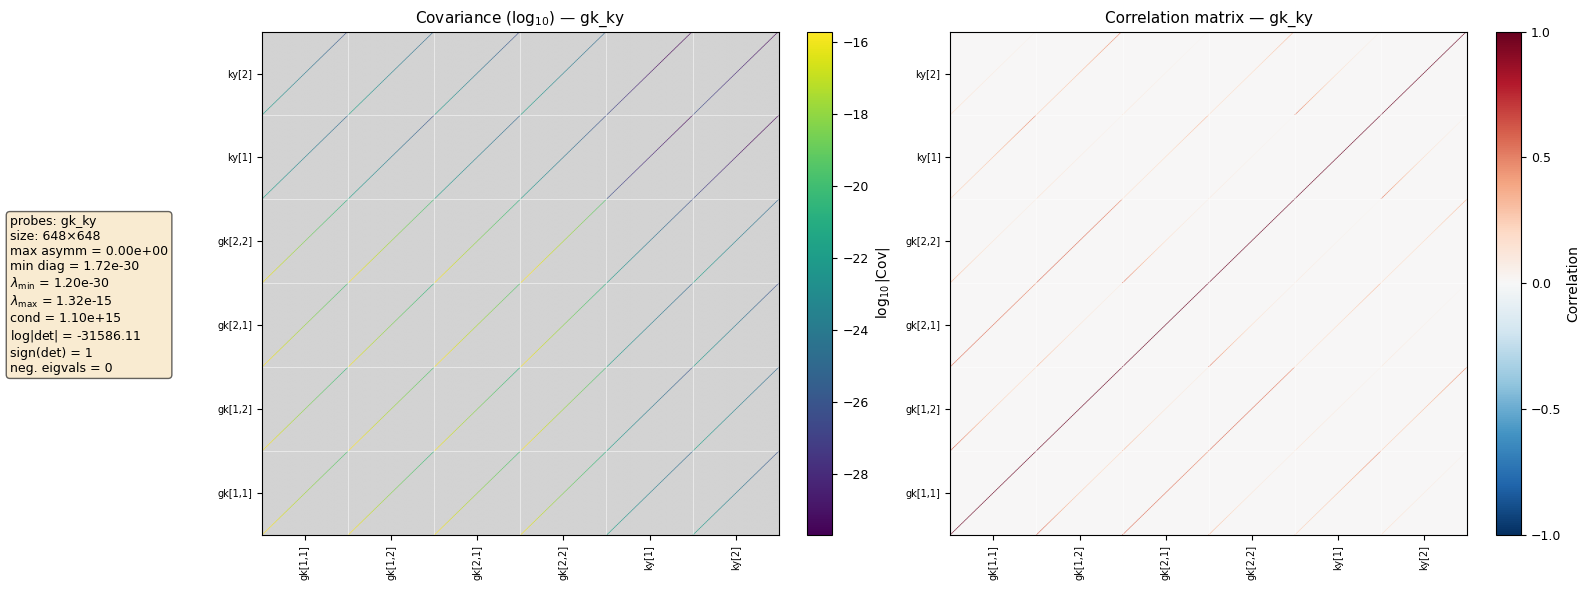

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_gk_ky.png

Probes: ['gy', 'ky']   [gy_ky]
  gy bin_combs: [[1, 0], [2, 0]]
  ky bin_combs: [[1, 0], [2, 0]]

  Full ordering:
    00: ('gy', (1, 0))
    01: ('gy', (2, 0))
    02: ('ky', (1, 0))
    03: ('ky', (2, 0))

  Matrix size : (432, 432)
  Max asymm.  : 0.000e+00
  Min diag    : 1.722e-30
  Max diag    : 5.311e-23
  Eigen min   : 1.121e-30
  Eigen max   : 7.062e-23
  Neg eigvals : 0 / 432
  Condition # : 6.302e+07
  log|det|    : -26499.946  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


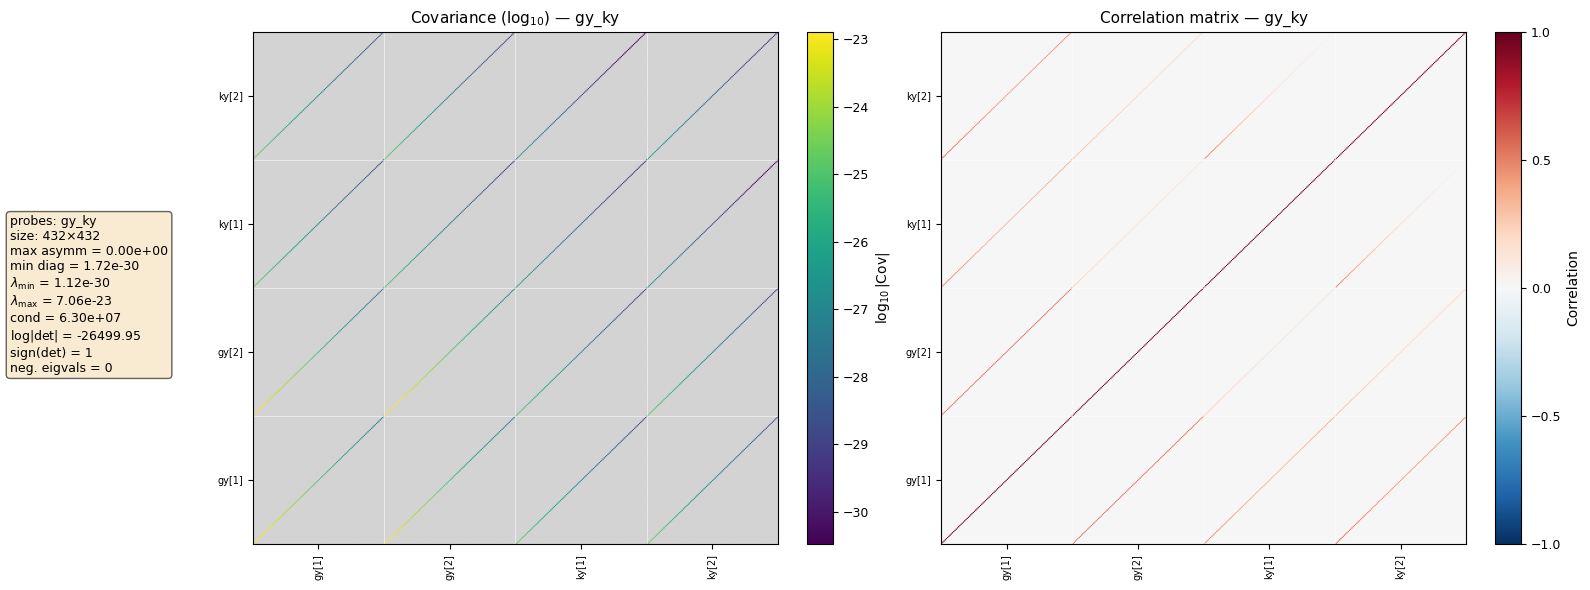

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_gy_ky.png

Probes: ['kk', 'gg', 'gk']   [kk_gg_gk]
  kk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gg bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]

  Full ordering:
    00: ('kk', (1, 1))
    01: ('kk', (1, 2))
    02: ('kk', (2, 2))
    03: ('gg', (1, 1))
    04: ('gg', (1, 2))
    05: ('gg', (2, 2))
    06: ('gk', (1, 1))
    07: ('gk', (1, 2))
    08: ('gk', (2, 1))
    09: ('gk', (2, 2))

  Matrix size : (1080, 1080)
  Max asymm.  : 0.000e+00
  Min diag    : 1.793e-22
  Max diag    : 7.424e-12
  Eigen min   : 1.345e-22
  Eigen max   : 1.014e-11
  Neg eigvals : 0 / 1080
  Condition # : 7.542e+10
  log|det|    : -43716.747  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


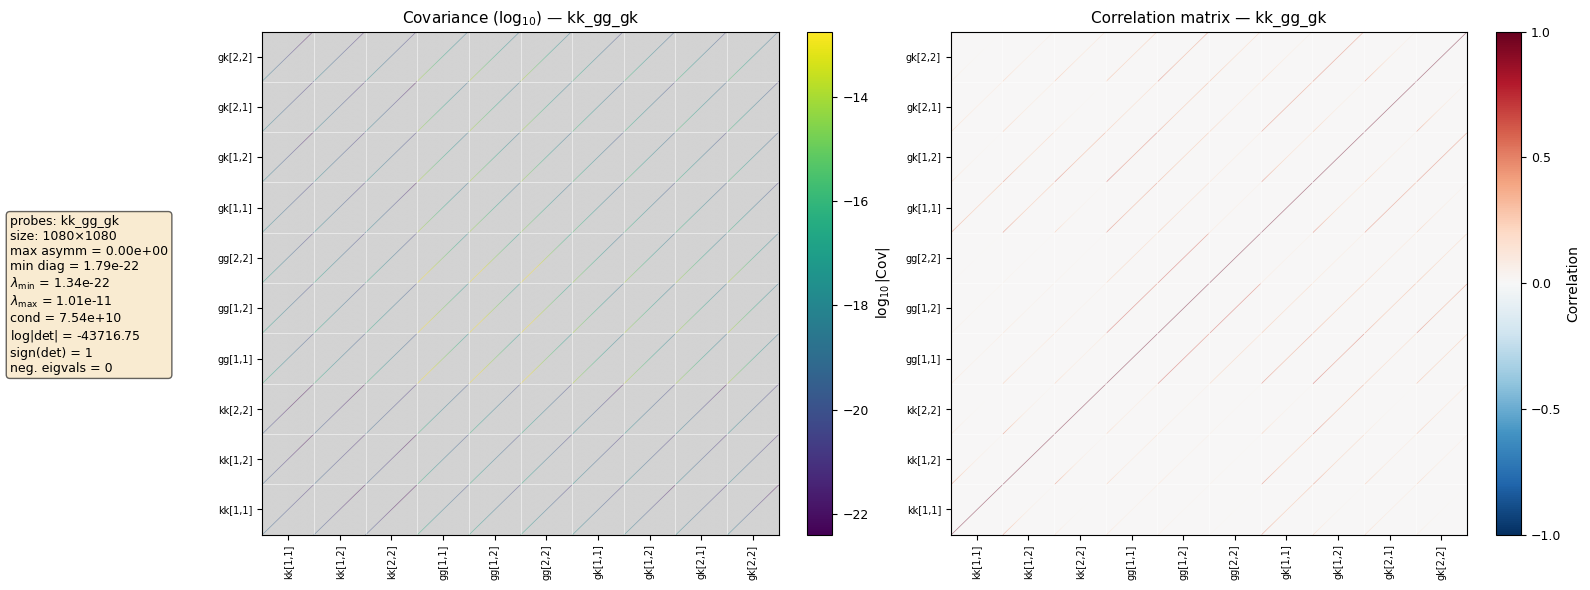

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_kk_gg_gk.png

Probes: ['kk', 'gg', 'gk', 'gy']   [kk_gg_gk_gy]
  kk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gg bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gy bin_combs: [[1, 0], [2, 0]]

  Full ordering:
    00: ('kk', (1, 1))
    01: ('kk', (1, 2))
    02: ('kk', (2, 2))
    03: ('gg', (1, 1))
    04: ('gg', (1, 2))
    05: ('gg', (2, 2))
    06: ('gk', (1, 1))
    07: ('gk', (1, 2))
    08: ('gk', (2, 1))
    09: ('gk', (2, 2))
    10: ('gy', (1, 0))
    11: ('gy', (2, 0))

  Matrix size : (1296, 1296)
  Max asymm.  : 0.000e+00
  Min diag    : 2.805e-28
  Max diag    : 7.424e-12
  Eigen min   : 8.806e-29
  Eigen max   : 1.014e-11
  Neg eigvals : 0 / 1296
  Condition # : 1.152e+17
  log|det|    : -56211.964  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


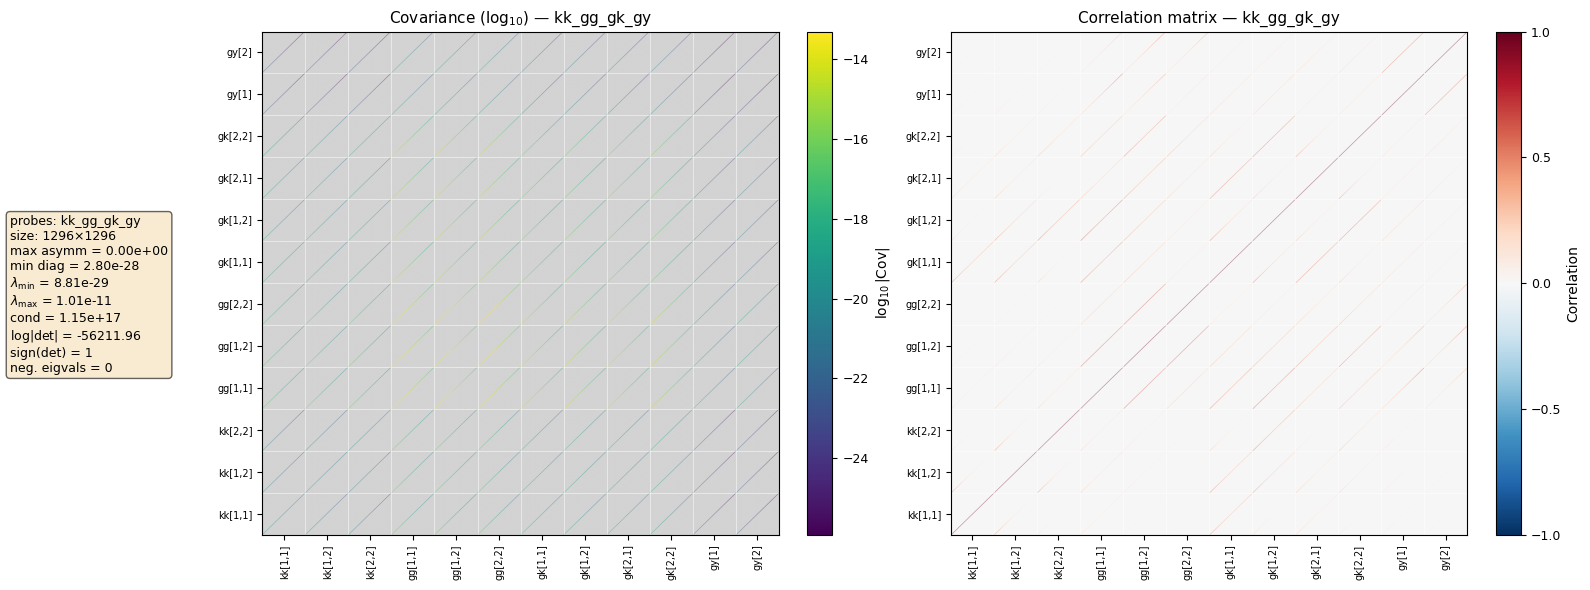

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_kk_gg_gk_gy.png

Probes: ['kk', 'gg', 'gk', 'ky']   [kk_gg_gk_ky]
  kk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gg bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  gk bin_combs: [[1, 1], [1, 2], [2, 1], [2, 2]]
  ky bin_combs: [[1, 0], [2, 0]]

  Full ordering:
    00: ('kk', (1, 1))
    01: ('kk', (1, 2))
    02: ('kk', (2, 2))
    03: ('gg', (1, 1))
    04: ('gg', (1, 2))
    05: ('gg', (2, 2))
    06: ('gk', (1, 1))
    07: ('gk', (1, 2))
    08: ('gk', (2, 1))
    09: ('gk', (2, 2))
    10: ('ky', (1, 0))
    11: ('ky', (2, 0))

  Matrix size : (1296, 1296)
  Max asymm.  : 0.000e+00
  Min diag    : 1.722e-30
  Max diag    : 7.424e-12
  Eigen min   : 1.110e-30
  Eigen max   : 1.014e-11
  Neg eigvals : 0 / 1296
  Condition # : 9.135e+18
  log|det|    : -57756.275  (sign = 1)
  NaN / Inf   : False / False


/tmp/ipykernel_1187357/1581932163.py:294: RuntimeWarning: divide by zero encountered in log10
  log_cov = np.log10(np.abs(cov_total))


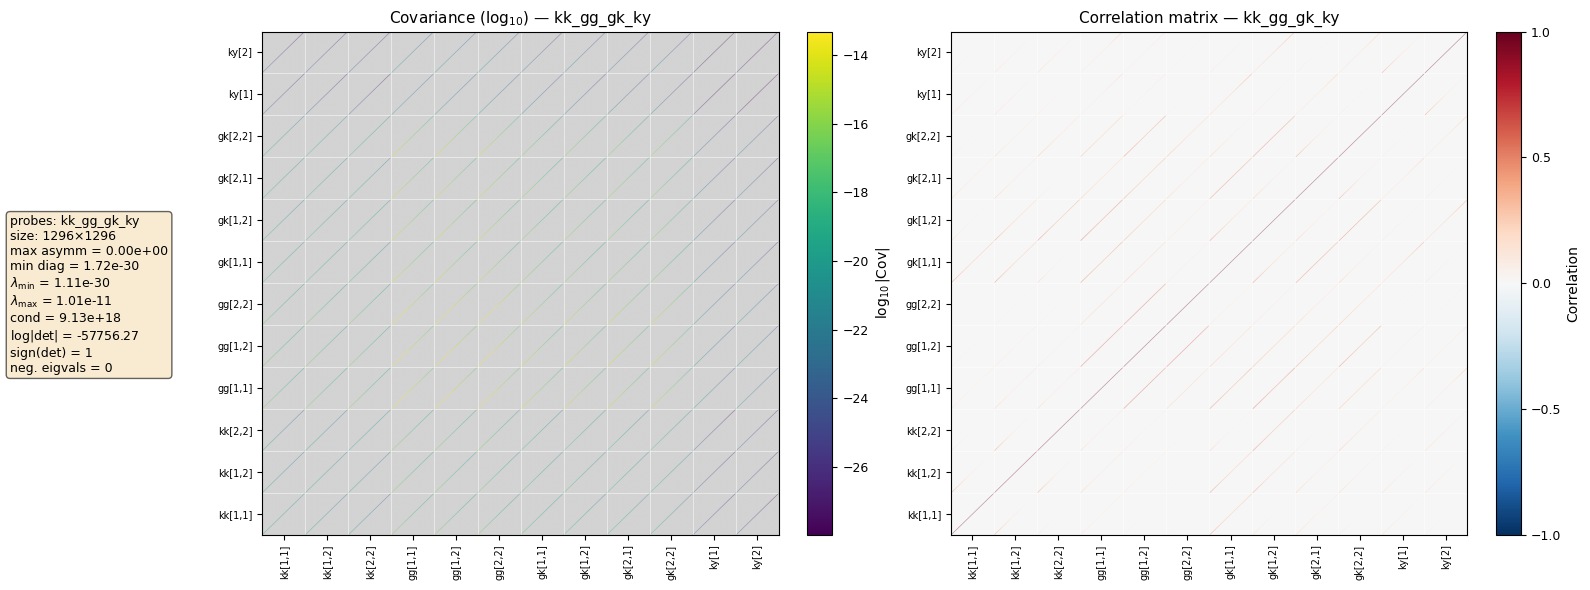

Saved: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/cov_corr_kk_gg_gk_ky.png


In [27]:

# Single probe 
res_kk = analyze_covariance(["kk"], cov_old, analysis_dict, abs_path_results) 
res_gg = analyze_covariance(["gg"], cov_old, analysis_dict, abs_path_results) 
res_yy = analyze_covariance(["yy"], cov_old, analysis_dict, abs_path_results) 
res_gy = analyze_covariance(["gy"], cov_old, analysis_dict, abs_path_results) 
res_ky = analyze_covariance(["ky"], cov_old, analysis_dict, abs_path_results) 
res_gk = analyze_covariance(["gk"], cov_old, analysis_dict, abs_path_results) 

# # Cross-probe subsets 
res_kk_gk = analyze_covariance(["kk", "gk"], cov_old, analysis_dict, abs_path_results) 
res_kk_gy = analyze_covariance(["kk", "gy"], cov_old, analysis_dict, abs_path_results) 
res_kk_ky = analyze_covariance(["kk", "ky"], cov_old, analysis_dict, abs_path_results)  
res_kk_gg = analyze_covariance(["kk", "gg"], cov_old, analysis_dict, abs_path_results)
res_kk_yy = analyze_covariance(["kk", "yy"], cov_old, analysis_dict, abs_path_results)

res_gk_gg = analyze_covariance(["gk", "gg"], cov_old, analysis_dict, abs_path_results) 
res_gy_gg = analyze_covariance(["gy", "gg"], cov_old, analysis_dict, abs_path_results) 
res_gg_ky = analyze_covariance(["gg", "ky"], cov_old, analysis_dict, abs_path_results) 
res_gg_yy = analyze_covariance(["gg", "yy"], cov_old, analysis_dict, abs_path_results)

res_gy_gk = analyze_covariance(["gy", "gk"], cov_old, analysis_dict, abs_path_results)
res_gg_ky = analyze_covariance(["gg", "ky"], cov_old, analysis_dict, abs_path_results) 
res_gk_ky = analyze_covariance(["gk", "ky"], cov_old, analysis_dict, abs_path_results) 
res_gy_ky = analyze_covariance(["gy", "ky"], cov_old, analysis_dict, abs_path_results) 

res_3x2 = analyze_covariance(["kk", "gg", "gk"], cov_old, analysis_dict, abs_path_results) 

res_kk_gg_gk_gy = analyze_covariance(["kk", "gg", "gk", "gy"], cov_old, analysis_dict, abs_path_results) 
res_kk_gg_gk_ky = analyze_covariance(["kk", "gg", "gk", "ky"], cov_old, analysis_dict, abs_path_results) 
# res_kk_gg_gk_yy = analyze_covariance(["kk", "gg", "gk", "yy"], cov_old, analysis_dict, abs_path_results) 
# res_kk_gg_gk_gy = analyze_covariance(["kk", "gg", "gk", "gy"], cov_old, analysis_dict, abs_path_results) 
# res_kk_gg_gk_ky = analyze_covariance(["kk", "gg", "gk", "ky"], cov_old, analysis_dict, abs_path_results) 
# res_kk_gg_gk_yy = analyze_covariance(["kk", "gg", "gk", "yy"], cov_old, analysis_dict, abs_path_results) 

# res_kk_gg_gk_gy_ky = analyze_covariance(["kk", "gg", "gk", "gy", "ky"], cov_old, analysis_dict, abs_path_results) 
# res_kk_gg_gk_gy_yy = analyze_covariance(["kk", "gg", "gk", "gy", "yy"], cov_old, analysis_dict, abs_path_results) 
# res_kk_gg_gk_ky_yy = analyze_covariance(["kk", "gg", "gk", "ky", "yy"], cov_old, analysis_dict, abs_path_results) 

# #Full set 
# res_all = analyze_covariance(["ky", "kk", "gy", "gg", "gk", "yy"], cov_old, analysis_dict, abs_path_results)

In [13]:
import pandas as pd


def summarize_covariance_results(results_dict):
    """
    Build a summary table from multiple analyze_covariance(...) outputs.

    Parameters
    ----------
    results_dict : dict
        Example:
            {
                "kk": res_kk,
                "gg": res_gg,
                "yy": res_yy,
                "kk_gk": res_kk_gk,
                ...
            }

    Returns
    -------
    df : pandas.DataFrame
        Summary table with one row per probe combination.
    """
    rows = []

    for name, res in results_dict.items():
        eigvals = np.array(res["eigvals"])
        eig_min = np.min(eigvals)
        eig_max = np.max(eigvals)

        ratio = np.nan
        if eig_max != 0:
            ratio = abs(eig_min) / eig_max

        rows.append({
            "probe_tag": name,
            "matrix_size": res["cov_total"].shape[0],
            "eig_min": eig_min,
            "eig_max": eig_max,
            "|eig_min|/eig_max": ratio,
            "n_neg": int(res["n_neg"]),
            "cond": res["cond"],
            "sign_det": res["sign_det"],
            "logdet": res["logdet"],
            "max_asymm": res["max_asymm"],
            "min_diag": res["min_diag"],
            "max_diag": res["max_diag"],
        })

    df = pd.DataFrame(rows)

    # optional: sort by probe name
    # df = df.sort_values("probe_tag").reset_index(drop=True)
    return df

all_results = {
    "kk": res_kk,
    "gg": res_gg,
    "yy": res_yy,
    "gy": res_gy,
    "ky": res_ky,
    "gk": res_gk,
    "3x2": res_3x2,
    "kk_gk": res_kk_gk,
    "kk_gy": res_kk_gy,
    "kk_ky": res_kk_ky,
    "gg_gk": res_gk_gg,
    "gg_gy": res_gy_gg,
    "gg_ky": res_gg_ky,
    "gk_gy": res_gy_gk,
    "gk_ky": res_gk_ky,
    "gy_ky": res_gy_ky,
    "kk_gg_gk_gy": res_kk_gg_gk_gy,
    "kk_gg_gk_ky": res_kk_gg_gk_ky,
    "kk_gg_gk_yy": res_kk_gg_gk_yy,
    "kk_gg_gk_gy_ky": res_kk_gg_gk_gy_ky,
    "kk_gg_gk_gy_yy": res_kk_gg_gk_gy_yy,
    "kk_gg_gk_ky_yy": res_kk_gg_gk_ky_yy,
    "all": res_all,
}

df_cov_summary = summarize_covariance_results(all_results)
print(df_cov_summary)

display(
    df_cov_summary.style.format({
        "eig_min": "{:.3e}",
        "eig_max": "{:.3e}",
        "|eig_min|/eig_max": "{:.3e}",
        "cond": "{:.3e}",
        "logdet": "{:.3f}",
        "max_asymm": "{:.3e}",
        "min_diag": "{:.3e}",
        "max_diag": "{:.3e}",
    })
)

summary_path = os.path.join(abs_path_results, "covariance_summary.csv")
df_cov_summary.to_csv(summary_path, index=False)
print(f"Saved summary table to: {summary_path}")

         probe_tag  matrix_size       eig_min       eig_max  \
0               kk          591  2.738439e-24  2.291007e-19   
1               gg          591  1.244981e-21  1.014281e-11   
2               yy          197  7.703996e-42  3.035192e-32   
3               gy          394  9.037715e-32  6.542839e-23   
4               ky          394  3.518321e-33  1.258342e-26   
5               gk          788  3.346895e-23  1.314590e-15   
6              3x2         1970 -3.155781e-18  1.014322e-11   
7            kk_gk         1379  2.661339e-24  1.314671e-15   
8            kk_gy          985  9.037707e-32  2.291019e-19   
9            kk_ky          985  3.518320e-33  2.291007e-19   
10           gg_gk         1379 -3.155552e-18  1.014322e-11   
11           gg_gy          985 -5.888960e-25  1.014281e-11   
12           gg_ky          985 -7.259447e-29  1.014281e-11   
13           gk_gy         1182 -1.010341e-27  1.314590e-15   
14           gk_ky         1182 -7.346705e-31  1.314590

,probe_tag,matrix_size,eig_min,eig_max,|eig_min|/eig_max,n_neg,cond,sign_det,logdet,max_asymm,min_diag,max_diag
0,kk,591,2.738e-24,2.291e-19,1.195e-05,0,8.366e+04,1.000000,-29003.685,0.000e+00,2.738e-24,1.631e-19
1,gg,591,1.245e-21,1.014e-11,1.227e-10,0,8.147e+09,1.000000,-22692.659,0.000e+00,2.707e-18,7.424e-12
2,yy,197,7.704e-42,3.035e-32,2.538e-10,0,3.940e+09,1.000000,-16880.387,0.000e+00,8.098e-42,2.842e-33
3,gy,394,9.038e-32,6.543e-23,1.381e-09,0,7.239e+08,1.000000,-24611.161,0.000e+00,1.118e-31,4.930e-23
4,ky,394,3.518e-33,1.258e-26,2.796e-07,0,3.577e+06,1.000000,-26899.240,0.000e+00,3.523e-33,6.224e-27
5,gk,788,3.347e-23,1.315e-15,2.546e-08,0,3.928e+07,1.000000,-34931.034,0.000e+00,3.747e-23,6.317e-16
6,3x2,1970,-3.156e-18,1.014e-11,3.111e-07,4,3.783e+12,1.000000,-86910.804,0.000e+00,2.738e-24,7.424e-12
7,kk_gk,1379,2.661e-24,1.315e-15,2.024e-09,0,4.940e+08,1.000000,-64036.616,0.000e+00,2.738e-24,6.317e-16
8,kk_gy,985,9.038e-32,2.291e-19,3.945e-13,0,2.535e+12,1.000000,-53615.967,0.000e+00,1.118e-31,1.631e-19
9,kk_ky,985,3.518e-33,2.291e-19,1.536e-14,0,6.512e+13,1.000000,-55908.084,0.000e+00,3.523e-33,1.631e-19


Saved summary table to: /home/vtinnane/Documents/Codes/develop/tSZxEuclid/notebooks/godmax/mock_tests/SO_noise/covariance_summary.csv


In [19]:
# Add to notebook — check Cauchy-Schwarz between diagonal blocks                                                               
print("\n=== Cauchy-Schwarz violations between diagonal blocks ===")  
cov_tot = res_kk_gy["cov_total"]  # or any other result you want to check
bin_all = res_kk_gy["bin_comb_all"]
bin_comb_all = res_kk_gy["bin_comb_all"]
cov_total = cov_tot                                                         
n_blocks = len(bin_comb_all)
nell = res_kk_gy["nell"]  # number of ell bins per block
for i in range(n_blocks):                                                                                                      
    for j in range(i+1, n_blocks):
        Cii = np.diag(np.array(cov_total[i*nell:(i+1)*nell, i*nell:(i+1)*nell]))                                               
        Cjj = np.diag(np.array(cov_total[j*nell:(j+1)*nell, j*nell:(j+1)*nell]))                                               
        Cij = np.diag(np.array(cov_total[i*nell:(i+1)*nell, j*nell:(j+1)*nell]))                                               
        # Cauchy-Schwarz: Cij^2 <= Cii * Cjj (element-wise at each ell)                                                        
        ratio = Cij**2 / (Cii * Cjj + 1e-300)                                                                                  
        n_viol = (ratio > 1.0).sum()                                                                                           
        max_viol = ratio.max()                                                                                                 
        pi, (ai, bi) = bin_comb_all[i]                                                                                         
        pj, (aj, bj) = bin_comb_all[j]                                                                                         
        if n_viol > 0:                                                                                                         
            print(f"  [{pi}({ai},{bi}) x {pj}({aj},{bj})]: "                                                                   
                f"{n_viol}/{nell} ell bins violate C-S, max ratio = {max_viol:.2f}")  
        elif max_viol > 0.9:                                                                                                 
            print(f"  [{pi}({ai},{bi}) x {pj}({aj},{bj})]: "                                                                   
                f"no violations but max ratio = {max_viol:.2f}")


=== Cauchy-Schwarz violations between diagonal blocks ===


Mock data computed
kk: shape=(141, 2, 2), combos=3, ell blocks=423

Expected total: 3 combos × 141 ell = 423
shape of data vector: (423,)


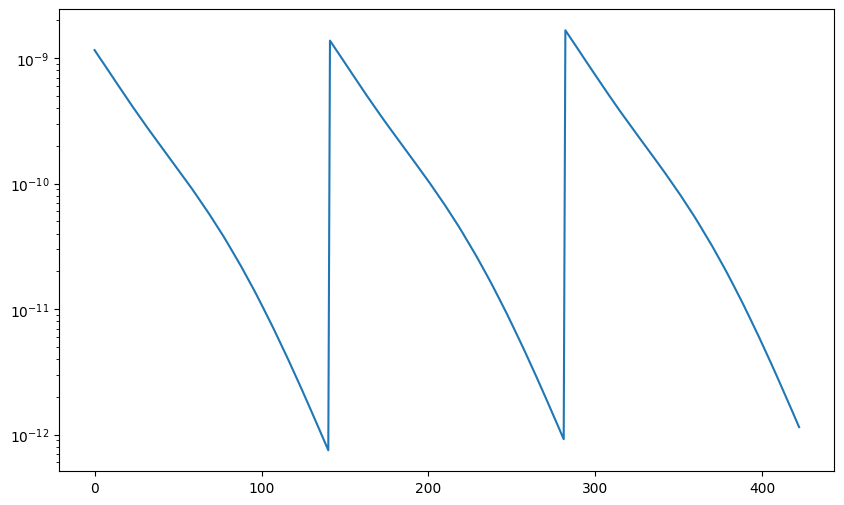

Cov matrix (423, 423) computed


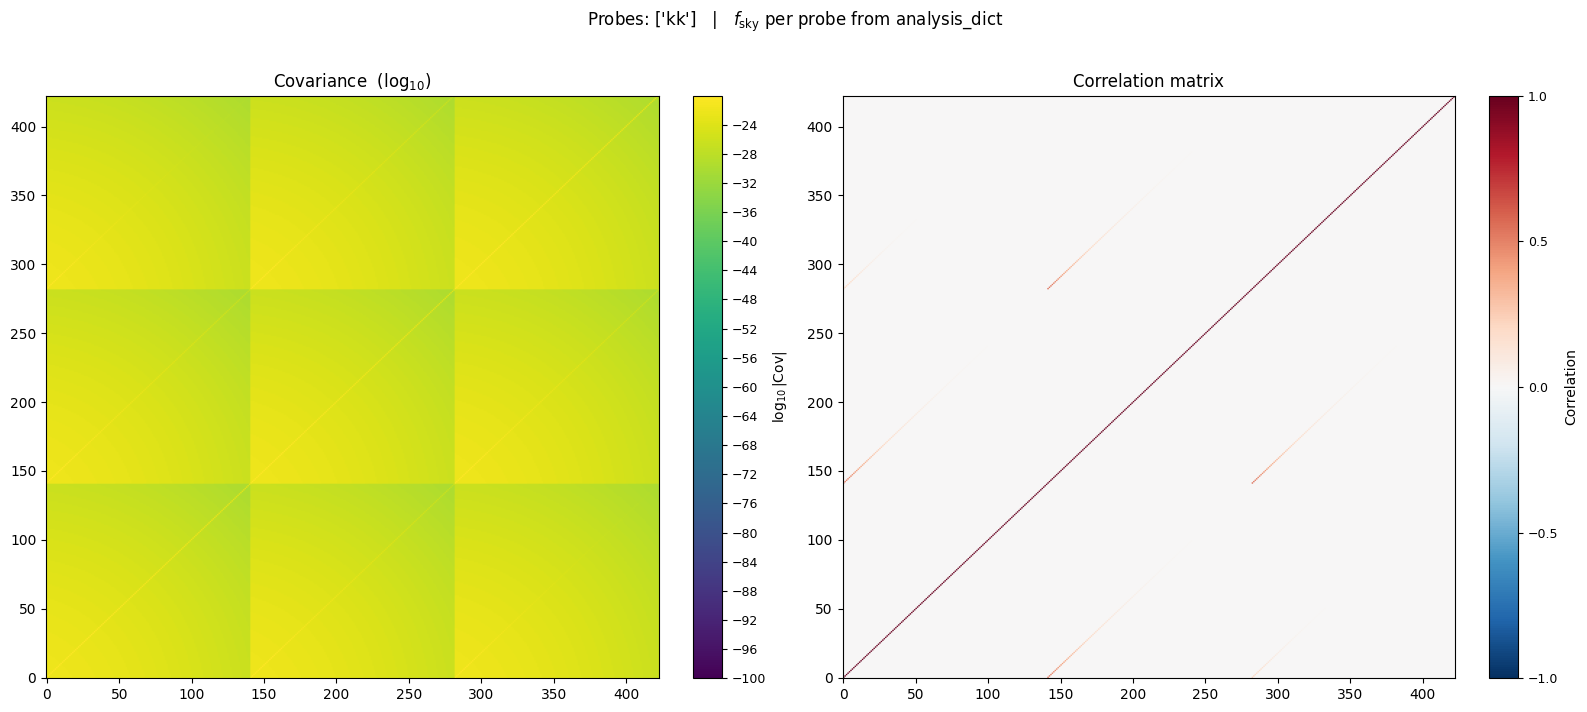

full cov:
Max asymmetry: 0.0
Any NaN: False
Any Inf: False
Any negative: False
Min eigenvalue: 1.9237676999986853e-24
Max eigenvalue: 1.6080143484826505e-19
eigen-max/abs(eigen-min): 83586.7214364681
Negative eigenvalues: []
Number of eigenvalues: (423,)
Cond: 83586.72143646805
Det: 0.0
Sign of determinant: 1.0
Logarithm of determinant: -20907.063365508788


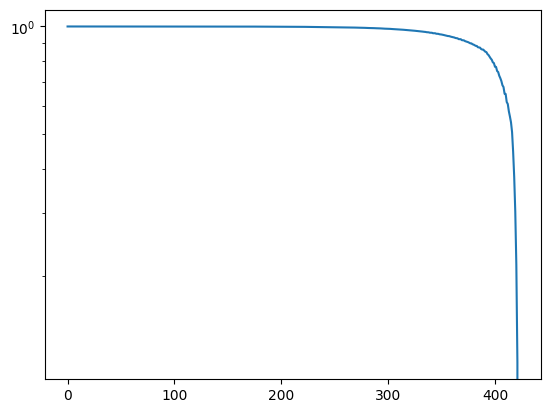

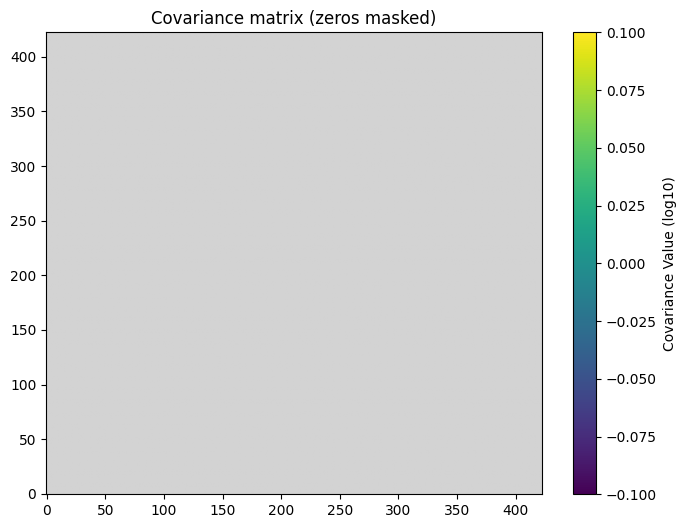

In [87]:
Cl_theory = {
    'ky': get_cl.Cl_kappa_y_tot_mat,
    'kk': get_cl.Cl_kappa_kappa_tot_mat,
    'gy': get_cl.Cl_gal_y_tot_mat,
    'gg': get_cl.Cl_gal_gal_tot_mat,
    'gk': get_cl.Cl_gal_kappa_tot_mat,
    'yy': get_cl.Cl_y_y_tot_mat
    
}

# probes_analysis = [ 'ky', 'kk',  'gy', 'gg', 'gk', 'yy']  
# probes_analysis = [ 'kk',  'gg', 'gk', 'yy','ky', 'gy']
probes_analysis = ['ky', 'kk', 'gy', 'gg', 'gk', 'yy'] 
probes_analysis = ['kk']  # order for plotting and data vector
labels = [r'$\langle  yy \rangle$', 
          r'$\langle  gk \rangle$',
          r'$\langle  kk \rangle$',
          r'$\langle  gg \rangle$']
# Compute the total number of ell bins for all probes and bin combinations
nell= len(analysis_dict['l_array_survey']) # (N_ell,)

for probe, arr in Cl_theory.items():
    if arr.shape[0] != nell:
        raise ValueError(f"{probe} has {arr.shape[0]} ell bins, expected {nell}")
    
nell_all = 0        # total number of ell bins for all probes and bin combinations (nell,nprobes,(nbins))
bin_comb_all = []   # dictionary with all bin combinations for each probe
for probe in probes_analysis:
    nell_probe, *bins = np.shape(Cl_theory[probe])
    if probe == 'yy':
          bin_comb_all.append([probe, (0, 0)])
    elif probe in ['gy','ky']: 
        for b1 in range(bins[0]):
            bin_comb_all.append([probe, (b1+1, 0)])
        #print(nell_probe, bins[0])
    
    elif probe in ['kk','gg']:
        #print(nell_probe, bins[0], bins[1])
        for b1 in range(bins[0]):
            for b2 in range(bins[1]):
                if b2 >= b1:
                    bin_comb_all.append([probe, (b1+1, b2+1)])
    elif probe in ['gk']:
        for b1 in range(bins[0]):
            for b2 in range(bins[1]):
                bin_comb_all.append([probe, (b1+1, b2+1)])

nell_all = len(bin_comb_all)*nell

# Fill data vector with all Cls
Cl_all = jnp.zeros((nell_all))

for i in range(len(bin_comb_all)):
    # Get probe and bin combination (b1 for probe 1, b2 for probe 2)
    comb_i = bin_comb_all[i]

    probe_i = comb_i[0]
    b1, b2 = comb_i[1][0], comb_i[1][1]
    #print(probe_i, b1, b2)
    sl = slice(i*nell, (i+1)*nell)
    if probe_i == 'yy':
          Cl_all = Cl_all.at[sl].set(get_cl.Cl_y_y_tot_mat)
    if probe_i == 'ky':
        Cl_all = Cl_all.at[sl].set(get_cl.Cl_kappa_y_tot_mat[:,b1-1])
    if probe_i == 'kk':
        Cl_all = Cl_all.at[sl].set(get_cl.Cl_kappa_kappa_tot_mat[:,b1-1,b2-1])
    if probe_i == 'gg':
        Cl_all = Cl_all.at[sl].set(get_cl.Cl_gal_gal_tot_mat[:,b1-1,b2-1])
    if probe_i == 'gk':
        Cl_all = Cl_all.at[sl].set(get_cl.Cl_gal_kappa_tot_mat[:,b1-1,b2-1])
    if probe_i == 'gy':
        Cl_all = Cl_all.at[sl].set(get_cl.Cl_gal_y_tot_mat[:,b1-1])

#print(np.shape(Cl_all))

data_vec = Cl_all.copy()  # mock data

# np.savetxt('../../../tests/mock-data/mock-Cls.txt', data_vec)
# np.savetxt('../../../tests/mock-data/mock-ell.txt', analysis_dict['l_array_survey'])
print('Mock data computed', flush=True)

for probe in probes_analysis:                                                                                                                    
    arr = Cl_theory[probe]
    _, *bins = np.shape(arr)                                                                                                                     
                
    if probe == 'yy':
        n = 1
    elif probe in ['gy', 'ky']:
        n = bins[0]
    elif probe in ['kk', 'gg']:
        n = bins[0] * (bins[0] + 1) // 2
    elif probe == 'gk':
        n = bins[0] * bins[1]

    print(f"{probe}: shape={np.shape(arr)}, combos={n}, ell blocks={n*nell}")

print(f"\nExpected total: {len(bin_comb_all)} combos × {nell} ell = {nell_all}")
print("shape of data vector:", np.shape(data_vec))

pl.figure(figsize=(10,6))
pl.semilogy(data_vec)
pl.show()

def full_cov_matrix(cov, bin_comb_all, nell, nell_all, verbose=False):
    cov_all = jnp.zeros((nell_all, nell_all))

    for i in range(len(bin_comb_all)):
        for j in range(len(bin_comb_all)):
            probe1, (b1, b2) = bin_comb_all[i]
            probe2, (b3, b4) = bin_comb_all[j]

            key     = f'bin_{b1}_{b2}_{b3}_{b4}'
            key_sym = f'bin_{b3}_{b4}_{b1}_{b2}'

            try:
                block = cov.covtot_dict[f'{probe1}_{probe2}'][key]
                path  = 'direct'
            except KeyError:
                block = cov.covtot_dict[f'{probe2}_{probe1}'][key_sym].T  # .T: block stored as Cov(p2,p1) but we need Cov(p1,p2)
                path  = 'transposed'

            cov_all = cov_all.at[i*nell:(i+1)*nell, j*nell:(j+1)*nell].set(block)

            if verbose:
                print(f"[{probe1}({b1},{b2}) x {probe2}({b3},{b4})] "
                    f"path={path}, "
                    f"min={float(block.min()):.3e}, max={float(block.max()):.3e}, "
                    f"diag_min={float(jnp.diag(block).min()):.3e}")

    cov_all = 0.5 * (cov_all + cov_all.T)
    return cov_all

# Then for block-by-block checks after building:

cov_total = full_cov_matrix(cov_old, bin_comb_all, nell, nell_all, verbose=False)

# Check each diagonal block (variance blocks)
# print("\n--- Diagonal block checks ---")
# for i, (probe, (b1, b2)) in enumerate(bin_comb_all):
#     block = np.array(cov_total[i*nell:(i+1)*nell, i*nell:(i+1)*nell])
#     eigvals = np.linalg.eigvalsh(block)
#     print(f"{probe}({b1},{b2}): "
#         f"diag range=[{np.diag(block).min():.3e}, {np.diag(block).max():.3e}], "
#         f"min_eigval={eigvals.min():.3e}, "
#         f"pos_definite={eigvals.min() > 0}")

print(f'Cov matrix {np.shape(cov_total)} computed', flush=True)


#############################################################################
########### PLOT COVARIANCE AND CORRELATION MATRICES ###########
##############################################################################
sigma = np.sqrt(np.diag(cov_total))
corr_old  = cov_total / np.outer(sigma, sigma)

fig, axes = pl.subplots(1, 2, figsize=(16, 7))                                                                                                   
                                                                                                                                                 
cmap_viridis = pl.cm.viridis.copy()                                                                                                              
cmap_viridis.set_bad(color='lightgray')                                                                                                        
                                                                                                                                                
cmap_rdbu = pl.cm.RdBu_r.copy()                                                                                                                
cmap_rdbu.set_bad(color='lightgray')

for ax, data, title, cmap, vmin, vmax, clabel, ticks in [
    (axes[0], np.log10(np.abs(cov_total)), 'Covariance  (log$_{10}$)', None, -100, -20, r'$\log_{10}|\mathrm{Cov}|$', np.arange(-100, -20,4)),
    (axes[1], corr_old,                  'Correlation matrix',        cmap_rdbu,    -1,   1,  'Correlation',                np.linspace(-1, 1,5)),]:
    im = ax.imshow(data, origin='lower', aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    cbar = pl.colorbar(im, ax=ax, label=clabel, fraction=0.046)
    cbar.set_ticks(ticks)
    cbar.ax.tick_params(labelsize=9)
    ax.set_facecolor('gray')
    ax.set_title(title)

pl.suptitle(f"Probes: {probes_analysis}   |   $f_{{\\rm sky}}$ per probe from analysis_dict", y=1.01)
pl.tight_layout()
# pl.savefig('../debug_plots/godmax_cov_corr_matrices_with_correction.png', dpi=150, bbox_inches='tight')
pl.show()

print('full cov:')
cov_total = cov_total
print("Max asymmetry:",np.max(np.abs(cov_total - cov_total.T)))

print("Any NaN:", np.isnan(cov_total).any())
print("Any Inf:", np.isinf(cov_total).any())
print("Any negative:", (cov_total < 0).any())

eigvals = np.linalg.eigvalsh(cov_total)

print("Min eigenvalue:", eigvals.min())
print("Max eigenvalue:", eigvals.max())
print("eigen-max/abs(eigen-min):", eigvals.max() / abs(eigvals.min()))

print('Negative eigenvalues:', eigvals[eigvals < 0])
print('Number of eigenvalues:', np.shape(eigvals))

cond = np.linalg.cond(cov_total)
print("Cond:",cond)

det = jnp.linalg.det(cov_total)
print("Det:",det)
sign, logdet = jnp.linalg.slogdet(cov_total)
print("Sign of determinant:", sign)
print("Logarithm of determinant:", logdet)

pl.plot((eigvals.max()-eigvals)/eigvals.max())
pl.yscale('log')
pl.show()

cov_np = np.array(cov_total - cov_total.T)

# Masquer les zéros
masked_cov = np.ma.masked_where(cov_np == 0, cov_np)

# Copier la colormap pour pouvoir modifier la couleur des masques
cmap = pl.cm.viridis.copy()
cmap.set_bad(color='lightgray')  # couleur des valeurs masquées

pl.figure(figsize=(8,6))
pl.imshow(masked_cov, cmap=cmap, aspect='auto', origin='lower')
pl.colorbar(label='Covariance Value (log10)')
pl.title("Covariance matrix (zeros masked)")
pl.show()


In [44]:



# #   - kk: [nell, nbins, nbins]  
# #   - ky: [nell, nbins]                                                            
# #   - gg: [nell, nbins_lens, nbins_lens]                                           
# #   - gk: [nell, nbins_lens, nbins]                                                
# #   - gy: [nell, nbins_lens]                                                       
# #   - yy: [nell]    


# ells = np.array(get_cl.ell_array)


# fig, axes = pl.subplots(2, 3, figsize=(15, 9))
# axes = axes.flatten()

# # --- kk: [nell, nbins, nbins] — plot auto-correlations (i==j) ---
# ax = axes[0]
# for i in range(Cl_theory['kk'].shape[1]):
#     cl = np.array(Cl_theory['kk'][:, i, i])
#     ax.loglog(ells, ells * (ells + 1) * cl / (2 * np.pi), label=f'bin {i+1}')
# ax.set_title(r'$\kappa\kappa$')
# ax.set_xlabel(r'$\ell$')
# ax.set_ylabel(r'$\ell(\ell+1)C_\ell/2\pi$')
# ax.legend(fontsize=7)

# # --- ky: [nell, nbins] ---
# ax = axes[1]
# for i in range(Cl_theory['ky'].shape[1]):
#     cl = np.array(Cl_theory['ky'][:, i])
#     ax.loglog(ells, ells * (ells + 1) * np.abs(cl) / (2 * np.pi), label=f'bin{i+1}')
# ax.set_title(r'$\kappa y$')
# ax.set_xlabel(r'$\ell$')
# ax.legend(fontsize=7)

# # --- gg: [nell, nbins_lens, nbins_lens] ---
# ax = axes[2]
# for i in range(Cl_theory['gg'].shape[1]):
#     cl = np.array(Cl_theory['gg'][:, i, i])
#     ax.loglog(ells, ells * (ells + 1) * cl / (2 * np.pi), label=f'bin {i+1}')
# ax.set_title(r'$gg$')
# ax.set_xlabel(r'$\ell$')
# ax.legend(fontsize=7)

# # --- gk: [nell, nbins_lens, nbins] — plot first lens bin vs all source bins

# ax = axes[3]
# for j in range(Cl_theory['gk'].shape[2]):
#     cl = np.array(Cl_theory['gk'][:, 0, j])
#     ax.loglog(ells, ells * (ells + 1) * np.abs(cl) / (2 * np.pi), label=f'src{j+1}')
# ax.set_title(r'$g\kappa$ (lens bin 1)')
# ax.set_xlabel(r'$\ell$')
# ax.legend(fontsize=7)

# # --- gy: [nell, nbins_lens] ---
# ax = axes[4]
# for i in range(Cl_theory['gy'].shape[1]):
#     cl = np.array(Cl_theory['gy'][:, i])
#     ax.loglog(ells, ells * (ells + 1) * np.abs(cl) / (2 * np.pi), label=f'bin{i+1}')
# ax.set_title(r'$gy$')
# ax.set_xlabel(r'$\ell$')
# ax.legend(fontsize=7)

# # --- yy: [nell] ---
# ax = axes[5]
# cl = np.array(get_cl.Cl_y_y_tot_mat)
# ax.loglog(ells, ells * (ells + 1) * Cl_theory['yy'] / (2 * np.pi))
# ax.set_title(r'$yy$')
# ax.set_xlabel(r'$\ell$')

# for ax in axes:
#     ax.set_ylabel(r'$\ell(\ell+1)C_\ell/2\pi$')
#     ax.grid(True, alpha=0.3)

# pl.tight_layout()
# # pl.savefig('godmax_cls.png', dpi=150)
# pl.show()


In [42]:
# def diagnose_cov_blocks(cov_old, save_dir=None):                                                                                                 
#     n_pairs = len(cov_old.covtot_dict)                                                                                                           
#     fig, axes = pl.subplots(n_pairs, 2, figsize=(13, 4 * n_pairs))

#     for ax_row, (probe_pair, pair_dict) in zip(axes, cov_old.covtot_dict.items()):
#         bin_key = [k for k in pair_dict if k != 'bins_comb'][0]  # one bin per probe pair

#         covtot = np.array(pair_dict[bin_key])
#         covG   = np.array(cov_old.covG_dict[probe_pair][bin_key])
#         covNG  = np.array(cov_old.covNG_dict[probe_pair][bin_key])

#         eigvals_tot = np.linalg.eigvalsh(covtot)
#         eigvals_G   = np.linalg.eigvalsh(covG)
#         eigvals_NG  = np.linalg.eigvalsh(covNG)

#         n_neg   = np.sum(eigvals_G < 0)
#         pos     = eigvals_tot[eigvals_G > 0]
#         cond    = eigvals_tot.max() / np.abs(pos.min()) if len(pos) > 0 else np.inf
#         title   = f'{probe_pair}  {bin_key}'
#         status  = 'PASS' if n_neg == 0 else f'WARN ({n_neg} neg)'
#         print(f"{title:50s}  min={eigvals_tot.min():.2e}  cond={cond:.2e}  {status}")

#         ax_row[0].semilogy(eigvals_tot[::-1], 'b-', lw=2,   label='covtot')
#         ax_row[0].semilogy(eigvals_G[::-1],   'g-', lw=1.5, alpha=0.8, label='covG')
#         ax_row[0].semilogy(np.abs(eigvals_NG[::-1]), 'r-', lw=1.5, alpha=0.8, label='|covNG|')
#         ax_row[0].set_title(f'{title}  |  neg={n_neg}  cond={cond:.1e}', fontsize=9)
#         ax_row[0].set_xlabel('Eigenvalue index (descending)')
#         ax_row[0].set_ylabel('Eigenvalue')
#         ax_row[0].legend(fontsize=9)
#         ax_row[0].grid(True, alpha=0.3)

#         im = ax_row[1].imshow(np.log10(np.abs(covtot)), aspect='auto', cmap='RdBu_r')
#         pl.colorbar(im, ax=ax_row[1], label=r'$\log_{10}|\mathrm{Cov}|$')
#         ax_row[1].set_title(f'covtot (log abs) — {title}', fontsize=9)
#         ax_row[1].set_xlabel(r'$\ell$ index')
#         ax_row[1].set_ylabel(r'$\ell$ index')

#     pl.tight_layout()
#     if save_dir:
#         pl.savefig(f'{save_dir}/cov_blocks_one_per_pair.png', dpi=100, bbox_inches='tight')
#     pl.show()

# diagnose_cov_blocks(cov_old, save_dir=None)

In [43]:
# eigvals = np.linalg.eigvalsh(np.array(cov_total))
# print(f"Min eigenvalue : {eigvals.min():.3e}")
# print(f"Max eigenvalue : {eigvals.max():.3e}")
# print(f"N zero eigvals : {np.sum(np.abs(eigvals) < 1e-30)}")
# print(f"N neg eigvals  : {np.sum(eigvals < 0)}")

# # Find which bin combos are linearly dependent
# print("\nCheck for duplicate bin combos:")
# seen = []
# for entry in bin_comb_all:
#     if entry in seen:
#         print(f"  DUPLICATE: {entry}")
#     seen.append(entry)

# # Check diagonal blocks are non-zero
# print("\nDiagonal block norms:")
# for i, (probe, (b1, b2)) in enumerate(bin_comb_all):
#     block = np.array(cov_total[i*nell:(i+1)*nell, i*nell:(i+1)*nell])
#     print(f"  {probe}({b1},{b2}): norm={np.linalg.norm(block):.3e}")


In [ ]:
# === BLOCK-LEVEL DIAGNOSTICS ===
import numpy as np

# 1. Check for duplicates in bin_comb_all
print('=== 1. Duplicate check in bin_comb_all ===')
seen = []
for entry in bin_comb_all:
    key = (entry[0], entry[1])
    if key in seen:
        print(f'  DUPLICATE: {entry}')
    else:
        seen.append(key)
print(f'  {len(bin_comb_all)} entries, {len(seen)} unique -> {"OK" if len(seen)==len(bin_comb_all) else "DUPLICATES FOUND"}')

# 2. Block-by-block path tracing (direct vs transposed) and norm matrix
print('
=== 2. Block lookup path and norms ===')
n_blocks = len(bin_comb_all)
block_norms = np.zeros((n_blocks, n_blocks))
block_paths = [['?' for _ in range(n_blocks)] for _ in range(n_blocks)]
block_asym  = np.zeros((n_blocks, n_blocks))  # asymmetry between (i,j) and (j,i).T

for i, (probe1, (b1, b2)) in enumerate(bin_comb_all):
    for j, (probe2, (b3, b4)) in enumerate(bin_comb_all):
        key     = f'bin_{b1}_{b2}_{b3}_{b4}'
        key_sym = f'bin_{b3}_{b4}_{b1}_{b2}'

        try:
            block = np.array(cov_old.covtot_dict[f'{probe1}_{probe2}'][key])
            path  = 'D'
        except KeyError:
            try:
                block = np.array(cov_old.covtot_dict[f'{probe2}_{probe1}'][key_sym])
                path  = 'T'   # <-- NOTE: block is B.T but used as B (missing .T in current code)
            except KeyError:
                block = np.zeros((nell, nell))
                path  = '0'

        block_norms[i, j] = np.linalg.norm(block)
        block_paths[i][j] = path

# Cross-check: for each (i,j) compare it against (j,i).T
print('Asymmetry between block(i,j) and block(j,i).T:')
found_asym = False
for i in range(n_blocks):
    for j in range(i+1, n_blocks):
        bij  = np.array(cov_old.covtot_dict.get(
                   f'{bin_comb_all[i][0]}_{bin_comb_all[j][0]}', {}).get(
                   f'bin_{bin_comb_all[i][1][0]}_{bin_comb_all[i][1][1]}_{bin_comb_all[j][1][0]}_{bin_comb_all[j][1][1]}', None))
        bji  = np.array(cov_old.covtot_dict.get(
                   f'{bin_comb_all[j][0]}_{bin_comb_all[i][0]}', {}).get(
                   f'bin_{bin_comb_all[j][1][0]}_{bin_comb_all[j][1][1]}_{bin_comb_all[i][1][0]}_{bin_comb_all[i][1][1]}', None))
        if bij is not None and bji is not None:
            asym = np.linalg.norm(bij - bji.T) / (np.linalg.norm(bij) + 1e-300)
            if asym > 1e-6:
                pi, (ai, ci) = bin_comb_all[i]
                pj, (aj, cj) = bin_comb_all[j]
                print(f'  [{pi}({ai},{ci}) x {pj}({aj},{cj})]: bij vs bji.T asym={asym:.2e}')
                found_asym = True
if not found_asym:
    print('  All checked pairs: bij == bji.T (OK)')

# 3. Diagonal block checks
print('
=== 3. Diagonal block checks ===')
for i, (probe, (b1, b2)) in enumerate(bin_comb_all):
    block = np.array(cov_total[i*nell:(i+1)*nell, i*nell:(i+1)*nell])
    eigvals_blk = np.linalg.eigvalsh(block)
    n_neg = (eigvals_blk < 0).sum()
    status = 'OK' if n_neg == 0 else f'WARN ({n_neg} neg eigvals)'
    print(f'  {probe}({b1},{b2}): norm={np.linalg.norm(block):.3e}, ' 
          f'diag=[{np.diag(block).min():.2e},{np.diag(block).max():.2e}], '
          f'eigmin={eigvals_blk.min():.2e}  -> {status}')

# 4. Block norm heatmap and path matrix
labels_blk = [f'{p}({b1},{b2})' for p, (b1, b2) in bin_comb_all]

fig, axes = pl.subplots(1, 2, figsize=(max(8,n_blocks*1.5+2), max(6,n_blocks*1.2+2)))

log_norms = np.log10(block_norms + 1e-300)
im0 = axes[0].imshow(log_norms, aspect='auto', origin='lower', cmap='viridis')
pl.colorbar(im0, ax=axes[0], label='log10(Frobenius norm)')
axes[0].set_title('Block Frobenius norm (log10)')
axes[0].set_xticks(range(n_blocks)); axes[0].set_yticks(range(n_blocks))
axes[0].set_xticklabels(labels_blk, rotation=45, ha='right', fontsize=8)
axes[0].set_yticklabels(labels_blk, fontsize=8)
for i in range(n_blocks):
    for j in range(n_blocks):
        axes[0].text(j, i, f'{log_norms[i,j]:.0f}', ha='center', va='center',
                     fontsize=6, color='white')

path_map = {'D': 2, 'T': 1, '0': 0}
path_matrix = np.array([[path_map.get(block_paths[i][j], 0)
                          for j in range(n_blocks)] for i in range(n_blocks)])
im1 = axes[1].imshow(path_matrix, aspect='auto', origin='lower',
                      cmap='RdYlGn', vmin=0, vmax=2)
pl.colorbar(im1, ax=axes[1], label='0=missing  1=transposed-without-.T  2=direct')
axes[1].set_title('Block lookup path
(green=direct, yellow=transposed*, red=missing)')
axes[1].set_xticks(range(n_blocks)); axes[1].set_yticks(range(n_blocks))
axes[1].set_xticklabels(labels_blk, rotation=45, ha='right', fontsize=8)
axes[1].set_yticklabels(labels_blk, fontsize=8)
for i in range(n_blocks):
    for j in range(n_blocks):
        axes[1].text(j, i, block_paths[i][j], ha='center', va='center', fontsize=8)

pl.tight_layout()
pl.show()
print('* T-path blocks: covtot_dict[p2_p1][key_sym] retrieved WITHOUT .T — see full_cov_matrix()')


In [44]:
cov_np  = np.array(cov_total)
cov_sym = 0.5 * (cov_np + cov_np.T)

eigvals, eigvecs = np.linalg.eigh(cov_sym)
neg_mask = eigvals < 0
n_neg = neg_mask.sum()

if n_neg > 0:
    max_neg = np.abs(eigvals[neg_mask]).max()
    max_pos = eigvals[eigvals > 0].max() if np.any(eigvals > 0) else np.nan
    frac = max_neg / max_pos if np.isfinite(max_pos) and max_pos > 0 else np.inf
else:
    frac = 0.0

print(f"Eigenvalue summary (shape {cov_sym.shape})")
print(f"  min = {eigvals.min():.3e}    max = {eigvals.max():.3e}")
print(f"  negative = {n_neg}")
if n_neg > 0:
    tag = "safe-ish numerical artifact" if frac < 1e-4 else "SIGNIFICANT — investigate model"
    print(f"  max|neg| / max_pos = {frac:.2e}  → {tag}")

# PSD projection
eigvals_clip = np.maximum(eigvals, 0.0)
cov_psd = eigvecs @ np.diag(eigvals_clip) @ eigvecs.T

# Pseudoinverse
cov_inv = np.linalg.pinv(cov_psd, rcond=1e-12)

# Rank / conditioning diagnostics
pos = eigvals_clip > 0
rank = pos.sum()
if rank > 0:
    cond = eigvals_clip[pos].max() / eigvals_clip[pos].min()
else:
    cond = np.inf

# Reconstruction check instead of C C^+ ~ I
recon_err = np.linalg.norm(cov_psd @ cov_inv @ cov_psd - cov_psd) / np.linalg.norm(cov_psd)

print(f"Effective rank     = {rank} / {cov_psd.shape[0]}")
print(f"Condition number   = {cond:.2e}")
print(f"||C C⁺ C - C||/||C|| = {recon_err:.2e}")

Eigenvalue summary (shape (18, 18))
  min = -1.237e-29    max = 1.965e-13
  negative = 2
  max|neg| / max_pos = 6.30e-17  → safe-ish numerical artifact
Effective rank     = 16 / 18
Condition number   = 8.01e+28
||C C⁺ C - C||/||C|| = 8.62e-13


In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# MCMC CELL 2 — Priors, fiducial theory, numerical Jacobian
#
# 4 free parameters:  Om0, sigma8, theta_ej_0, A_IA
# Linearisation: T(θ) ≈ T(θ_fid) + J · (θ - θ_fid)
# J is computed with central differences (8 get_Cl calls) then frozen.
#
# T_fid = data_vec directly — data_vec IS the fiducial prediction, so
# log_p(θ_fid) = 0 exactly and no recomputation is needed.
# compute_theory uses the same Cl extraction loop as the data_vec cell above
# so Jacobian columns are consistent with data_vec.
# ─────────────────────────────────────────────────────────────────────────────

# =====================================================================
#                             PRIORS
# =====================================================================
prior_min = {"Om0": 0.1,  "sigma8": 0.5, "theta_ej_0": 1.0, "A_IA": -1.0}
prior_max = {"Om0": 0.6,  "sigma8": 1.1, "theta_ej_0": 8.0, "A_IA":  1.0}

cosmo_params_vary_names = ["Om0", "sigma8"]
phys_params_vary_names  = ["theta_ej_0"]
other_params_vary_names = ["A_IA"]

param_names = cosmo_params_vary_names + phys_params_vary_names + other_params_vary_names

# ── Fiducial values (read from loaded param dicts) ────────────────────────────
theta_fid_dict = {
    "Om0"       : sim_params_dict['cosmo']['Om0'],      # 0.31
    "sigma8"    : sim_params_dict['cosmo']['sigma8'],   # 0.81
    "theta_ej_0": sim_params_dict['theta_ej_0'],        # 2.0
    "A_IA"      : other_params_dict['A_IA'],            # 0.1
}
theta_fid_vec = jnp.array([theta_fid_dict[p] for p in param_names])

# data_vec is the fiducial prediction — use it directly as T_fid
data_np = np.array(data_vec)
T_fid   = data_np.copy()   # guarantees log_p(θ_fid) = 0 exactly

print("Fiducial θ:", {p: float(theta_fid_dict[p]) for p in param_names})
print(f"T_fid = data_vec  (shape {T_fid.shape})")


def compute_theory(Om0, sigma8, theta_ej_0, A_IA):
    """
    Theory data vector using exactly the same Cl extraction as the data_vec
    cell — same probe order, same bin indexing — so the Jacobian is consistent.
    """
    sp = copy.deepcopy(sim_params_dict)
    op = copy.deepcopy(other_params_dict)
    sp['cosmo']['Om0']    = float(Om0)
    sp['cosmo']['sigma8'] = float(sigma8)
    sp['theta_ej_0']      = float(theta_ej_0)
    op['A_IA']            = float(A_IA)
    cl = get_Cl(sp, halo_params_dict, analysis_dict, op)

    Cl_out = np.zeros(nell_all)
    for i, (probe_i, (b1, b2)) in enumerate(bin_comb_all):
        sl = slice(i * nell, (i + 1) * nell)
        if probe_i == 'yy':
            Cl_out[sl] = np.array(cl.Cl_y_y_tot_mat)
        elif probe_i == 'ky':
            Cl_out[sl] = np.array(cl.Cl_kappa_y_tot_mat[:, b1 - 1])
        elif probe_i == 'kk':
            Cl_out[sl] = np.array(cl.Cl_kappa_kappa_tot_mat[:, b1 - 1, b2 - 1])
        elif probe_i == 'gg':
            Cl_out[sl] = np.array(cl.Cl_gal_gal_tot_mat[:, b1 - 1, b2 - 1])
        elif probe_i == 'gk':
            Cl_out[sl] = np.array(cl.Cl_gal_kappa_tot_mat[:, b1 - 1, b2 - 1])
        elif probe_i == 'gy':
            Cl_out[sl] = np.array(cl.Cl_gal_y_tot_mat[:, b1 - 1])
    return Cl_out


# ── Central-difference Jacobian ───────────────────────────────────────────────
eps = {"Om0": 0.01, "sigma8": 0.01, "theta_ej_0": 0.1, "A_IA": 0.05}
dT  = {}

for p in param_names:
    kw = dict(theta_fid_dict)
    print(f"\nComputing ∂T/∂{p}  (ε = {eps[p]}) ...", flush=True)
    t1 = time.time()
    kw[p] = theta_fid_dict[p] + eps[p];  Tp = compute_theory(**kw)
    kw[p] = theta_fid_dict[p] - eps[p];  Tm = compute_theory(**kw)
    dT[p] = (Tp - Tm) / (2.0 * eps[p])
    print(f"  done in {time.time()-t1:.1f}s   "
          f"range [{dT[p].min():.3e}, {dT[p].max():.3e}]")

# jac shape: (nell_all, n_params)
jac = jnp.array(np.column_stack([dT[p] for p in param_names]))
print(f"\nJacobian shape: {jac.shape}   columns → {param_names}")


Fiducial θ: {'Om0': 0.3, 'sigma8': 0.8, 'theta_ej_0': 2.0, 'A_IA': -0.5}
T_fid = data_vec  (shape (1254,))

Computing ∂T/∂Om0  (ε = 0.01) ...
Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
  done in 32.7s   range [-5.996e-05, 2.228e-07]

Computing ∂T/∂sigma8  (ε = 0.01) ...
Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
  done in 30.9s   range [3.751e-17, 1.238e-05]

Computing ∂T/∂theta_ej_0  (ε = 0.1) ...
Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
  done in 32.4s   range [-1.069e-09, 1.647e-09]

Computing ∂T/∂A_IA  (ε = 0.05) ...
Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
Loaded yy noise from file; Cl_y_y_tot_mat = theory + noise
  done in 31.1s   range [-5.462e-08, 0.000e+00]

Jacobian shape: (1254, 4)   columns → ['Om0', 'sigma8', 'theta_ej_0', 'A_IA']


In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# MCMC CELL 3 — NUTS model and sampling
# ─────────────────────────────────────────────────────────────────────────────
T_fid_jax   = jnp.array(T_fid)
cov_inv_jax = jnp.array(cov_inv)
data_jax    = jnp.array(data_np)


def model():
    # ── Uniform priors ────────────────────────────────────────────────────────
    theta = jnp.stack([
        numpyro.sample(p, dist.Uniform(prior_min[p], prior_max[p]))
        for p in param_names
    ])

    # ── Linearised theory — fully JAX-differentiable ──────────────────────────
    dtheta = theta - theta_fid_vec
    theory = T_fid_jax + jac @ dtheta

    # ── Gaussian log-likelihood ───────────────────────────────────────────────
    diff = data_jax - theory
    numpyro.factor('log_likelihood', -0.5 * diff @ cov_inv_jax @ diff)


# ── Sanity check: log-posterior at fiducial should be 0.0 ────────────────────
log_p_fid = numpyro.infer.util.log_density(
    model, (), {}, {p: theta_fid_dict[p] for p in param_names})[0]
print(f"log-posterior at fiducial = {float(log_p_fid):.6f}   (want 0.0)")

# ── Run NUTS ──────────────────────────────────────────────────────────────────
n_warmup  = 50
n_samples = 10000

nuts = NUTS(
    model,
    dense_mass        = True,
    adapt_mass_matrix = True,
    adapt_step_size   = True,
    max_tree_depth    = 8,
)
mcmc = MCMC(
    nuts,
    num_warmup   = n_warmup,
    num_samples  = n_samples,
    num_chains   = 1,
    progress_bar = True,
)

print(f"\nRunning NUTS  ({n_warmup} warmup + {n_samples} samples) ...", flush=True)
t0 = time.time()
mcmc.run(jax.random.PRNGKey(42))
print(f"Done in {time.time()-t0:.1f}s\n")

mcmc.print_summary()
samples = mcmc.get_samples()


log-posterior at fiducial = -1.435085   (want 0.0)

Running NUTS  (50 warmup + 10000 samples) ...


sample: 100%|██████████| 10050/10050 [02:44<00:00, 60.96it/s, 39 steps of size 1.15e-01. acc. prob=0.94]


Done in 164.9s


                  mean       std    median      5.0%     95.0%     n_eff     r_hat
        A_IA     -0.50      0.03     -0.50     -0.55     -0.45   2138.37      1.00
         Om0      0.30      0.01      0.30      0.29      0.31   6889.22      1.00
      sigma8      0.80      0.01      0.80      0.79      0.81   5133.68      1.00
  theta_ej_0      2.00      0.26      2.00      1.57      2.43   3622.85      1.00

Number of divergences: 0


Om0             =  0.2999  ±  0.0053   (fid = 0.3000)
sigma8          =  0.8002  ±  0.0086   (fid = 0.8000)
theta_ej_0      =  2.0018  ±  0.2642   (fid = 2.0000)
A_IA            =  -0.5001  ±  0.0296   (fid = -0.5000)


arviz - WARNING - Shape validation failed: input_shape: (1, 10000), minimum_shape: (chains=2, draws=4)



             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
Om0         0.300  0.005   0.290    0.310      0.000    0.000    6874.0   
sigma8      0.800  0.009   0.784    0.816      0.000    0.000    5114.0   
theta_ej_0  2.002  0.264   1.523    2.521      0.004    0.003    3611.0   
A_IA       -0.500  0.030  -0.558   -0.448      0.001    0.000    2137.0   

            ess_tail  r_hat  
Om0           7111.0    NaN  
sigma8        6739.0    NaN  
theta_ej_0    2628.0    NaN  
A_IA          2492.0    NaN  


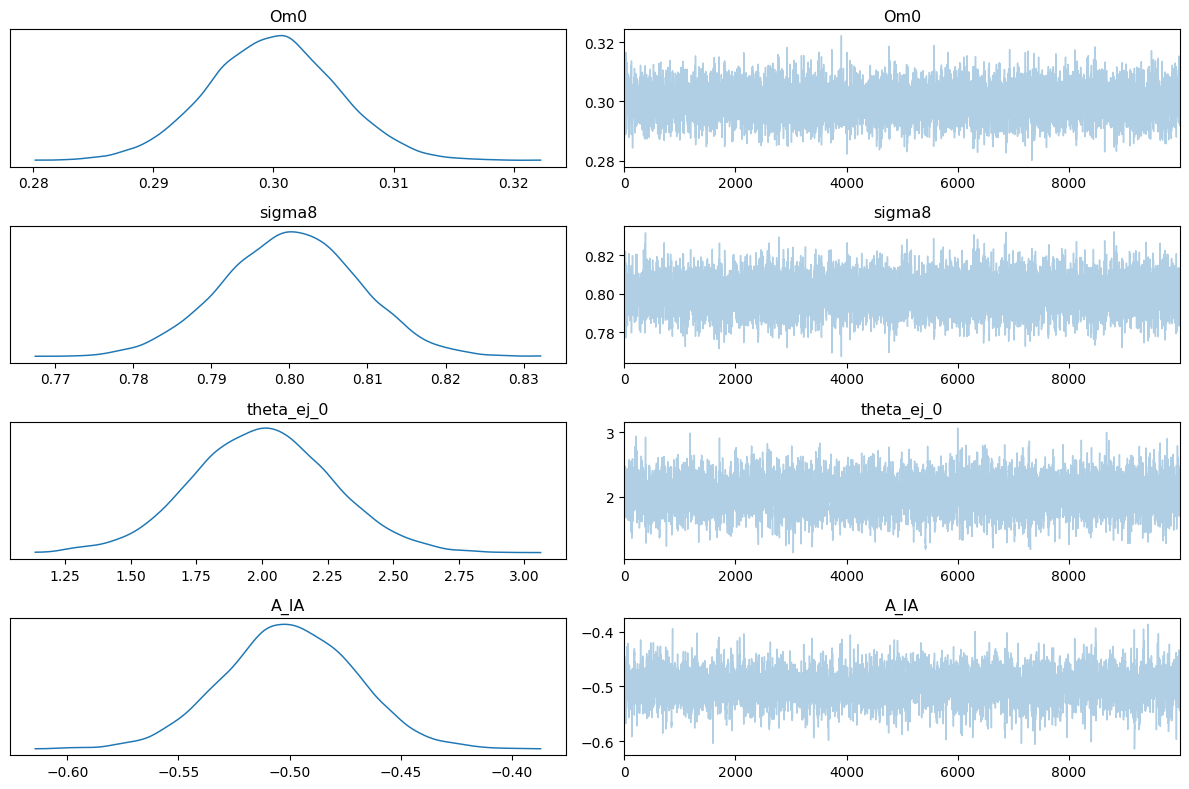

Removed no burn in


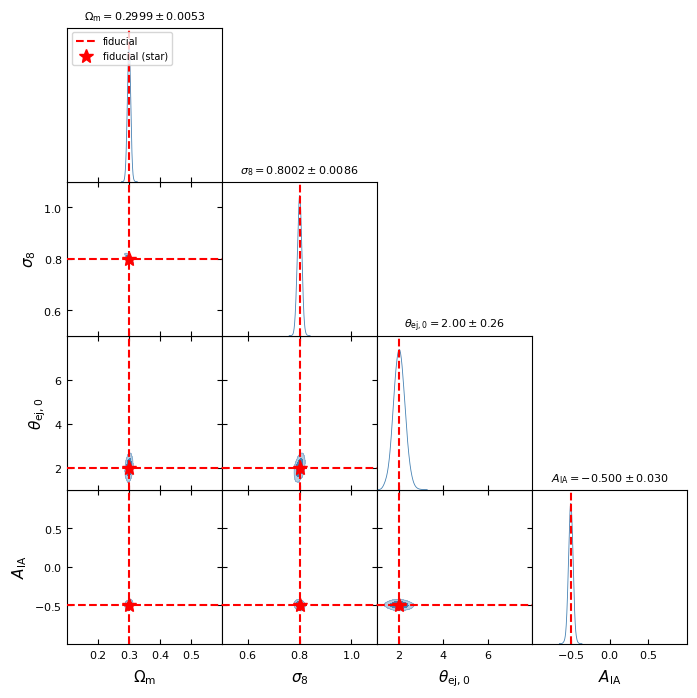

In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# MCMC CELL 4 — Diagnostics and triangle plot
# ─────────────────────────────────────────────────────────────────────────────
chains = {p: np.array(samples[p]) for p in param_names}

for p in param_names:
    print(f"{p:<15s} =  {chains[p].mean():.4f}  ±  {chains[p].std():.4f}"
          f"   (fid = {theta_fid_dict[p]:.4f})")

# ── Arviz summary (R-hat, ESS) ───────────────────────────────────────────────
idata = az.from_numpyro(mcmc)
print()
print(az.summary(idata, var_names=param_names))

# ── Trace plots ──────────────────────────────────────────────────────────────
az.plot_trace(idata, var_names=param_names)
pl.tight_layout()
# pl.savefig('../../../tests/mock-data/mcmc_trace.png', dpi=150, bbox_inches='tight')
pl.show()

# ── Triangle / corner plot ────────────────────────────────────────────────────
latex_labels = {
    'Om0'       : r'\Omega_{\rm m}',
    'sigma8'    : r'\sigma_8',
    'theta_ej_0': r'\theta_{\rm ej,0}',
    'A_IA'      : r'A_{\rm IA}',
}

gd_samples = MCSamples(
    samples  = np.column_stack([chains[p] for p in param_names]),
    names    = param_names,
    labels   = [latex_labels[p] for p in param_names],
    settings = {'smooth_scale_2D': 0.4, 'smooth_scale_1D': 0.4},
)

# Force axis limits to prior range so prior-bound lines are always visible
param_limits = {p: (prior_min[p], prior_max[p]) for p in param_names}

g = plots.get_subplot_plotter(width_inch=8)
g.triangle_plot(
    [gd_samples],
    param_names,
    filled         = True,
    contour_colors = ['steelblue'],
    title_limit    = 1,
    param_limits   = param_limits,
)

# ── Annotate each panel ───────────────────────────────────────────────────────
fiducials = [theta_fid_dict[p] for p in param_names]
p_min     = [prior_min[p]      for p in param_names]
p_max     = [prior_max[p]      for p in param_names]
n_params  = len(param_names)

for row in range(n_params):
    for col in range(row + 1):
        ax = g.subplots[row, col]
        if ax is None:
            continue

        if row == col:
            # 1-D marginal: prior bounds + fiducial line + star
            # ax.axvline(p_min[col],     color='gray', ls=':',  lw=1.5, zorder=4)
            # ax.axvline(p_max[col],     color='gray', ls=':',  lw=1.5, zorder=4)
            ax.axvline(fiducials[col], color='r',    ls='--', lw=1.5, zorder=5)
            # ylo, yhi = ax.get_ylim()
            # ax.plot(fiducials[col], ylo + 0.05 * (yhi - ylo),
            #         '*', color='r', ms=10, zorder=6, clip_on=False)
        else:
            # 2-D panel: prior bounds (all 4 edges) + fiducial crosshair + star
            # ax.axvline(p_min[col],     color='gray', ls=':',  lw=1.5, zorder=4)
            # ax.axvline(p_max[col],     color='gray', ls=':',  lw=1.5, zorder=4)
            # ax.axhline(p_min[row],     color='gray', ls=':',  lw=1.5, zorder=4)
            # ax.axhline(p_max[row],     color='gray', ls=':',  lw=1.5, zorder=4)
            ax.axvline(fiducials[col], color='r',    ls='--', lw=1.5, zorder=5)
            ax.axhline(fiducials[row], color='r',    ls='--', lw=1.5, zorder=5)
            ax.plot(fiducials[col], fiducials[row],
                    '*', color='r', ms=10, zorder=6)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    pl.Line2D([0], [0], color='r',    ls='--',   lw=1.5,            label='fiducial'),
    pl.Line2D([0], [0], color='r',    ls='None', marker='*', ms=10, label='fiducial (star)'),
    # pl.Line2D([0], [0], color='gray', ls=':',    lw=1.5,            label='prior bounds'),
]
g.subplots[0, 0].legend(handles=legend_handles, fontsize=7, loc='upper left')

# pl.savefig('../../../tests/mock-data/mcmc_contours.png', dpi=150, bbox_inches='tight')
pl.show()
